<a href="https://colab.research.google.com/github/ederbsilveira/Projeto_Monografia_SI_Unisinos_2026/blob/main/apuracao_pesquisa_base_tratada.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# pacotes básicos
import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import math



In [3]:
# montar pasta Google Drive

# carrega as biblioteca de montagem de driver
from google.colab import drive

# montar Google Drive / mount Google drive será solicitadas as credenciais do usuario do gmail
drive.mount('/content/gdrive',force_remount=True)

Mounted at /content/gdrive


In [4]:
def analisar_coluna(df, nome_coluna, cor_principal="viridis"):
    """
    Gera um gráfico estatístico e uma tabela de frequências para a coluna informada.
    Suporta colunas categóricas (texto) e numéricas (escalas).
    """
    # Verifica se a coluna realmente existe no DataFrame
    if nome_coluna not in df.columns:
        print(f"❌ Erro: A coluna '{nome_coluna}' não foi encontrada no DataFrame.")
        return

    print(f"📊 --- ANÁLISE COMPLETA: {nome_coluna} --- 📊\n")

    # 1. GERAÇÃO DA TABELA DE FREQUÊNCIAS (Dados Absolutos e Percentuais)
    contagem = df[nome_coluna].value_counts(dropna=True)
    percentual = df[nome_coluna].value_counts(normalize=True, dropna=True) * 100

    tabela_frequencia = pd.DataFrame({
        'Frequência Absoluta': contagem,
        'Proporção (%)': percentual.round(2)
    })
    print(tabela_frequencia)
    print("\n" + "-"*60 + "\n")

    # 2. CONFIGURAÇÃO DO GRÁFICO
    plt.figure(figsize=(11, 5))

    # Caso A: A coluna é numérica (como as escalas de 1 a 10)
    if pd.api.types.is_numeric_dtype(df[nome_coluna]):
        sns.histplot(data=df, x=nome_coluna, kde=True, bins=10, color="#2b5c8f")
        plt.title(f"Distribuição de Frequência - {nome_coluna}", fontsize=12, fontweight='bold', pad=15)
        plt.xlabel("Escala / Nota", fontsize=10)
        plt.ylabel("Contagem de respostas", fontsize=10)

    # Caso B: A coluna é de texto/categoria (maioria do questionário)
    else:
        # Define uma paleta de cores limpa
        paleta = sns.color_palette(cor_principal, n_colors=len(contagem))

        # Plot horizontal para garantir legibilidade dos textos das respostas
        sns.countplot(
            data=df,
            y=nome_coluna,
            order=contagem.index,
            palette=paleta,
            hue=nome_coluna,
            legend=False
        )
        plt.title(f"Distribuição por Categoria - {nome_coluna}", fontsize=12, fontweight='bold', pad=15)
        plt.xlabel("Contagem de respostas", fontsize=10)
        plt.ylabel("", fontsize=10) # Remove o nome da coluna no eixo Y para não poluir

    # Ajusta o layout para o texto não cortar e exibe o gráfico
    plt.tight_layout()
    plt.show()

In [5]:
def analisar_coluna_ordinal(df, nome_coluna, ordem_correta, cor_principal="Blues_r"):
    """
    Gera um gráfico de barras e tabela de frequências para variáveis categóricas ordinais,
    respeitando a ordem lógica definida pelo usuário.
    """
    if nome_coluna not in df.columns:
        print(f"❌ Erro: A coluna '{nome_coluna}' não foi encontrada.")
        return

    print(f"📊 --- ANÁLISE ORDINAL: {nome_coluna} --- 📊\n")

    # 1. TABELA DE FREQUÊNCIA (Forçando a ordem que você definiu)
    contagem = df[nome_coluna].value_counts().reindex(ordem_correta, fill_value=0)
    percentual = (df[nome_coluna].value_counts(normalize=True) * 100).reindex(ordem_correta, fill_value=0)

    tabela_frequencia = pd.DataFrame({
        'Frequência Absoluta': contagem,
        'Proporção (%)': percentual.round(2)
    })
    print(tabela_frequencia)
    print("\n" + "-"*60 + "\n")

    # 2. CONFIGURAÇÃO DO GRÁFICO HORIZONTAL
    plt.figure(figsize=(11, 5))

    # Criamos um degradê de cores para dar a sensação de escala/crescimento
    paleta = sns.color_palette(cor_principal, n_colors=len(ordem_correta))

    # O segredo aqui é o argumento 'order', que força o Seaborn a seguir a sua lista
    sns.countplot(
        data=df,
        y=nome_coluna,
        order=ordem_correta,
        palette=paleta,
        hue=nome_coluna,
        legend=False
    )

    plt.title(f"Distribuição - {nome_coluna}", fontsize=12, fontweight='bold', pad=15)
    plt.xlabel("Contagem de respostas", fontsize=10)
    plt.ylabel("", fontsize=10)

    plt.tight_layout()
    plt.show()

In [6]:
def analisar_cruzamento_separado(df, coluna_x, coluna_separadora, ordem_x=None, ordem_separadora=None, cor_base="Blues_r"):
    """
    Gera tabelas estatísticas e plota gráficos de barras em quadros separados (subplots)
    para cada categoria da coluna_separadora, evitando poluição visual.
    """
    if coluna_x not in df.columns or coluna_separadora not in df.columns:
        print("❌ Erro: Uma ou ambas as colunas não foram encontradas no DataFrame.")
        return

    print(f"🔄 --- ANÁLISE EM QUADROS: {coluna_x} por {coluna_separadora} --- 📊\n")

    # 1. EMISSÃO DAS TABELAS NO CONSOLE (Para manter o rigor estatístico)
    tabela_absoluta = pd.crosstab(df[coluna_x], df[coluna_separadora])
    tabela_percentual = pd.crosstab(df[coluna_x], df[coluna_separadora], normalize='index') * 100

    if ordem_x:
        tabela_absoluta = tabela_absoluta.reindex(ordem_x)
        tabela_percentual = tabela_percentual.reindex(ordem_x)
    if ordem_separadora:
        tabela_absoluta = tabela_absoluta.reindex(columns=ordem_separadora)
        tabela_percentual = tabela_percentual.reindex(columns=ordem_separadora)

    print("📋 Tabela de Frequência Absoluta (Contagem):")
    display(tabela_absoluta)
    print("\n📈 Tabela Percentual Relativa (Distribuição % por linha):")
    display(tabela_percentual.round(1))
    print("\n" + "-"*80 + "\n")

    # 2. CONFIGURAÇÃO DA GRADE DINÂMICA DE GRÁFICOS
    # Descobre quais categorias existem para criar os quadros
    categorias_separadoras = ordem_separadora if ordem_separadora else sorted(df[coluna_separadora].dropna().unique())
    num_quadros = len(categorias_separadoras)

    # Define a grade: 2 colunas por linha
    num_colunas_grade = 2
    num_linhas_grade = math.ceil(num_quadros / num_colunas_grade)

    # Cria a figura com o tamanho proporcional ao número de linhas necessárias
    fig, axes = plt.subplots(nrows=num_linhas_grade, ncols=num_colunas_grade,
                             figsize=(14, 4 * num_linhas_grade), sharex=True)

    # Achata a matriz de eixos para um vetor para facilitar o loop de plotagem
    axes = axes.flatten() if num_quadros > 1 else [axes]

    # Determina a ordem do eixo Y dos subplots
    ordem_plot_y = ordem_x if ordem_x else df[coluna_x].value_counts().index

    # Define a paleta de cores para o degradê interno das barras de cada quadro
    paleta = sns.color_palette(cor_base, n_colors=len(ordem_plot_y))

    # 3. LOOP DE PLOTAGEM - Um quadro para cada categoria
    for i, cat in enumerate(categorias_separadoras):
        ax = axes[i]

        # Filtra os dados pertencentes apenas àquela categoria específica
        dados_filtrados = df[df[coluna_separadora] == cat]

        # Plota o gráfico de barras horizontais no quadro atual
        sns.countplot(
            data=dados_filtrados,
            y=coluna_x,
            order=ordem_plot_y,
            palette=paleta,
            hue=coluna_x,
            legend=False,
            ax=ax
        )

        # Customizações estéticas por quadro
        ax.set_title(f"📌 {coluna_separadora}: {cat}", fontsize=11, fontweight='bold', color="#1a365d")
        ax.set_xlabel("Nº de Respondentes" if i >= (num_quadros - num_colunas_grade) else "")
        ax.set_ylabel("")
        ax.xaxis.get_major_locator().set_params(integer=True) # Força o eixo X a exibir apenas números inteiros
        sns.despine(ax=ax) # Limpa as bordas superior e direita do gráfico para ficar clean

    # 4. LIMPEZA DE QUADROS EXTRAS (Se houver número ímpar de categorias, desativa o quadro que sobrou em branco)
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(pad=2.0)
    plt.show()

In [7]:
def analisar_cruzamento_separado_pct(df, coluna_x, coluna_separadora, ordem_x=None, ordem_separadora=None, cor_base="Blues_r", margem_folga=20):
    """
    Gera tabelas estatísticas e plota gráficos de barras em quadros separados (subplots)
    exibindo a proporção em PERCENTUAL (%) no eixo X e adicionando rótulos de dados
    com o valor exato ao lado de cada barra horizontal.
    """
    if coluna_x not in df.columns or coluna_separadora not in df.columns:
        print("❌ Erro: Uma ou ambas as colunas não foram encontradas no DataFrame.")
        return

    print(f"🔄 --- ANÁLISE EM QUADROS (PERCENTUAL % COM RÓTULOS): {coluna_x} por {coluna_separadora} --- 📊\n")

    # 1. EMISSÃO DAS TABELAS NO CONSOLE
    tabela_absoluta = pd.crosstab(df[coluna_x], df[coluna_separadora])
    tabela_percentual = pd.crosstab(df[coluna_x], df[coluna_separadora], normalize='columns') * 100

    if ordem_x:
        tabela_absoluta = tabela_absoluta.reindex(ordem_x)
        tabela_percentual = tabela_percentual.reindex(ordem_x)
    if ordem_separadora:
        tabela_absoluta = tabela_absoluta.reindex(columns=ordem_separadora)
        tabela_percentual = tabela_percentual.reindex(columns=ordem_separadora)

    print("📋 Tabela de Frequência Absoluta (Contagem):")
    display(tabela_absoluta)
    print("\n📈 Tabela Percentual Relativa (Distribuição % por coluna/quadro):")
    display(tabela_percentual.round(1))
    print("\n" + "-"*80 + "\n")

    # 2. MAPEAMENTO DOS DADOS E CÁLCULO DO MÁXIMO DINÂMICO
    categorias_separadoras = ordem_separadora if ordem_separadora else sorted(df[coluna_separadora].dropna().unique())
    ordem_plot_y = ordem_x if ordem_x else df[coluna_x].value_counts().index

    quadros_dados = {}
    maior_percentual_global = 0

    for cat in categorias_separadoras:
        dados_filtrados = df[df[coluna_separadora] == cat]
        total_do_quadro = len(dados_filtrados)

        if total_do_quadro > 0:
            df_pct = (dados_filtrados[coluna_x].value_counts() / total_do_quadro * 100).reindex(ordem_plot_y, fill_value=0).reset_index()
            df_pct.columns = [coluna_x, 'PERCENTUAL']
            quadros_dados[cat] = (df_pct, total_do_quadro)

            max_local = df_pct['PERCENTUAL'].max()
            if max_local > maior_percentual_global:
                maior_percentual_global = max_local
        else:
            quadros_dados[cat] = (None, 0)

    # Limite dinâmico com folga arredondada
    limite_x_dinamico = min(100, maior_percentual_global + margem_folga)
    limite_x_dinamico = math.ceil(limite_x_dinamico / 5) * 5

    # 3. CONFIGURAÇÃO DA GRADE DINÂMICA
    num_quadros = len(categorias_separadoras)
    num_colunas_grade = 2
    num_linhas_grade = math.ceil(num_quadros / num_colunas_grade)

    fig, axes = plt.subplots(nrows=num_linhas_grade, ncols=num_colunas_grade,
                             figsize=(14, 4 * num_linhas_grade), sharex=True)

    axes = axes.flatten() if num_quadros > 1 else [axes]
    paleta = sns.color_palette(cor_base, n_colors=len(ordem_plot_y))

    # 4. LOOP DE PLOTAGEM COM INJEÇÃO DOS RÓTULOS (BAR_LABEL)
    for i, cat in enumerate(categorias_separadoras):
        ax = axes[i]
        df_pct, total_do_quadro = quadros_dados[cat]

        if df_pct is not None:
            plots = sns.barplot(
                data=df_pct,
                x='PERCENTUAL',
                y=coluna_x,
                palette=paleta,
                hue=coluna_x,
                legend=False,
                ax=ax
            )

            # --- INJEÇÃO DOS PERCENTUAIS AO LADO DAS BARRAS ---
            # Percorre os containers de barras criados pelo Seaborn no quadro atual
            for container in ax.containers:
                ax.bar_label(
                    container,
                    fmt='%.1f%%',          # Formato: uma casa decimal e símbolo de %
                    padding=6,             # Afastamento horizontal da ponta da barra
                    fontsize=9,            # Tamanho da fonte do rótulo
                    fontweight='semibold', # Peso da fonte para ficar nítido
                    color='#333333'        # Cor discreta e profissional
                )

        # Customizações estéticas por quadro
        ax.set_title(f"{coluna_separadora}: {cat}", fontsize=11, fontweight='bold', color="#1a365d")
        ax.set_xlabel("Proporção (%)" if i >= (num_quadros - num_colunas_grade) else "")
        ax.set_ylabel("")

        ax.set_xlim(0, limite_x_dinamico)
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x)}%'))
        sns.despine(ax=ax)

    # 5. LIMPEZA DE QUADROS EXTRAS
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout(pad=2.0)
    plt.show()

In [8]:
def reclassificar_formacao(df):
    """
    Interpreta as respostas de múltipla escolha da coluna AREAS_FORMACAO
    e cria a coluna consolidada PERFIL_FORMACAO.
    """
    # Criamos variáveis booleanas (True/False) temporárias para identificar a presença de cada bloco
    tem_ti = df['AREAS_FORMACAO'].str.contains('Tecnologia da Informação', na=False)
    tem_financas = df['AREAS_FORMACAO'].str.contains('Finanças e Negócios', na=False)

    # Criamos uma lista de condições lógicas
    condicoes = [
        (tem_ti & tem_financas),         # Regra 1: Tem ambas as formações
        (tem_ti & ~tem_financas),        # Regra 2: Tem TI, mas não Finanças
        (~tem_ti & tem_financas)         # Regra 3: Não tem TI, mas tem Finanças
    ]

    # Lista de rótulos equivalentes para cada condição acima
    rotulos = [
        "TI e Negócios/Finanças",
        "Exclusivamente TI",
        "Exclusivamente Finanças/Negócios"
    ]

    # O np.select avalia as condições em ordem. O que não entrar em nenhuma vira o 'default' (Outras Áreas)
    df['PERFIL_FORMACAO'] = np.select(condicoes, rotulos, default="Outras Formações")

    return df

In [9]:
def gerar_painel_comparativo(df, variavel_ancora, lista_variaveis_comparar, ordens_dicionario=None, cor_base="Blues_r"):
    """
    Gera um painel comparativo de subplots ligando 1 variável âncora (eixo Y)
    com até 5 outras variáveis (eixo X em %).

    df: DataFrame ativo
    variavel_ancora: A variável que define as linhas/grupos de comparação (Eixo Y)
    lista_variaveis_comparar: Lista com até 5 nomes de colunas do dataframe
    ordens_dicionario: Dicionário contendo as listas de ordens para cada variável (opcional)
    """
    # Garante o limite de variáveis para não quebrar o layout da tela
    if len(lista_variaveis_comparar) > 5:
        print("❌ Limite excedido: Escolha no máximo 5 variáveis para comparar com a âncora.")
        return

    print(f"📊 --- PAINEL COMPARATIVO MULTIVARIÁVEL: ÂNCORA [{variavel_ancora}] --- 📊\n")

    num_variaveis = len(lista_variaveis_comparar)

    # Criar a matriz de gráficos: 1 linha para a âncora, N colunas para as comparadas
    fig, axes = plt.subplots(nrows=1, ncols=num_variaveis, figsize=(5 * num_variaveis, 6), sharey=True)

    # Se for apenas 1 variável externa, transforma o axes em lista para o loop funcionar
    if num_variaveis == 1: axes = [axes]

    # Ordem do eixo Y (Âncora)
    ordem_y = ordens_dicionario.get(variavel_ancora, None) if ordens_dicionario else None
    if ordem_y is None:
        ordem_y = df[variavel_ancora].value_counts().index.tolist()

    paleta = sns.color_palette(cor_base, n_colors=len(ordem_y))

    # Loop para construir cada um dos quadros do painel
    for idx, var_coluna in enumerate(lista_variaveis_comparar):
        ax = axes[idx]

        # Ordem das categorias dentro do gráfico atual (Legenda/Agrupamento)
        ordem_hue = ordens_dicionario.get(var_coluna, None) if ordens_dicionario else None

        # Gera o countplot calculando os volumes lógicos
        sns.countplot(
            data=df,
            y=variavel_ancora,
            hue=var_coluna,
            order=ordem_y,
            hue_order=ordem_hue,
            palette="viridis",
            ax=ax
        )

        # Transforma o eixo X em percentual dinâmico para aquele quadro
        # Descobre o total de respondentes válidos para aquela combinação de colunas
        total_validos = df[[variavel_ancora, var_coluna]].notna().all(axis=1).sum()

        # Ajusta os rótulos de dados nas barras com o % real ponderado
        for container in ax.containers:
            # Calcula o percentual baseado no total da amostra do quadro
            labels = []
            for bar in container:
                width = bar.get_width()
                pct = (width / total_validos * 100) if total_validos > 0 else 0
                labels.append(f'{pct:.1f}%' if width > 0 else '')

            ax.bar_label(container, labels=labels, padding=4, fontsize=8, fontweight='semibold')

        # Ajustes estéticos de enquadramento limpo
        ax.set_title(f"🔍 vs {var_coluna}", fontsize=11, fontweight='bold', pad=10, color="#1a365d")
        ax.set_xlabel("Proporção na Amostra (%)", fontsize=9)
        ax.set_ylabel("" if idx > 0 else variavel_ancora) # Só mostra o rótulo do eixo Y no primeiro quadro
        ax.legend(title=var_coluna, bbox_to_anchor=(0.5, -0.15), loc='upper center', fontsize=8, title_fontsize=9)
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

In [10]:
def gerar_painel_comparativo_labels(df, variavel_ancora, lista_variaveis_comparar, ordens_dicionario=None, dicionario_labels=None, cor_base="Blues_r"):
    """
    Gera o painel comparativo original (eixo Y compartilhado), adicionando a flexibilidade
    de traduzir siglas para os rótulos/perguntas reais através do dicionario_labels.
    """
    if len(lista_variaveis_comparar) > 5:
        print("❌ Limite excedido: Escolha no máximo 5 variáveis para comparar com a âncora.")
        return

    # Identifica o texto de exibição da variável âncora
    label_ancora = dicionario_labels.get(variavel_ancora, variavel_ancora) if dicionario_labels else variavel_ancora
    print(f"📊 --- PAINEL COMPARATIVO MULTIVARIÁVEL: ÂNCORA [{label_ancora}] --- 📊\n")

    num_variaveis = len(lista_variaveis_comparar)

    # Cria a matriz original de gráficos lado a lado compartilhando o eixo Y
    fig, axes = plt.subplots(nrows=1, ncols=num_variaveis, figsize=(5.5 * num_variaveis, 6), sharey=True)

    if num_variaveis == 1: axes = [axes]

    # Recupera a ordem do eixo Y (Âncora)
    ordem_y = ordens_dicionario.get(variavel_ancora, None) if ordens_dicionario else None
    if ordem_y is None:
        ordem_y = df[variavel_ancora].value_counts().index.tolist()

    # Loop para construir os quadros exatamente como no modelo original que você gostou
    for idx, var_coluna in enumerate(lista_variaveis_comparar):
        ax = axes[idx]

        # Identifica os textos reais por extenso para a coluna atual
        label_coluna = dicionario_labels.get(var_coluna, var_coluna) if dicionario_labels else var_coluna
        ordem_hue = ordens_dicionario.get(var_coluna, None) if ordens_dicionario else None

        # Desenha o countplot no formato original
        sns.countplot(
            data=df,
            y=variavel_ancora,
            hue=var_coluna,
            order=ordem_y,
            hue_order=ordem_hue,
            palette="viridis",
            ax=ax
        )

        # Calcula a proporção percentual ponderada para os rótulos de dados
        total_validos = df[[variavel_ancora, var_coluna]].notna().all(axis=1).sum()

        for container in ax.containers:
            labels = []
            for bar in container:
                width = bar.get_width()
                pct = (width / total_validos * 100) if total_validos > 0 else 0
                labels.append(f'{pct:.1f}%' if width > 0 else '')

            ax.bar_label(container, labels=labels, padding=4, fontsize=8, fontweight='semibold')

        # Aplica a tradução dinamicamente nos títulos e legendas
        ax.set_title(f"🔍 vs {label_coluna}", fontsize=10, fontweight='bold', pad=12, color="#1a365d")
        ax.set_xlabel("Proporção na Amostra (%)", fontsize=9)
        ax.set_ylabel(label_ancora if idx == 0 else "") # Traduz a âncora apenas no primeiro eixo Y

        # Posiciona a legenda abaixo de cada quadro usando o nome limpo/pergunta
        ax.legend(title=label_coluna, bbox_to_anchor=(0.5, -0.18), loc='upper center', fontsize=8, title_fontsize=9)
        sns.despine(ax=ax)

    plt.tight_layout()
    plt.show()

In [11]:
def gerar_painel_comparativo_labels_2x2(df, variavel_ancora, lista_variaveis_comparar, ordens_dicionario=None, dicionario_labels=None):
    """
    Gera um painel comparativo em formato de quadrante 2x2, ideal para comparar
    exatamente 4 subafirmações (como na matriz Likert da H1).
    """
    if len(lista_variaveis_comparar) != 4:
        print("❌ Para o layout 2x2, passe exatamente 4 variáveis na 'lista_variaveis_comparar'.")
        return

    # Identifica o texto de exibição da variável âncora
    label_ancora = dicionario_labels.get(variavel_ancora, variavel_ancora) if dicionario_labels else variavel_ancora
    print(f"📊 --- PAINEL COMPARATIVO 2x2: ÂNCORA [{label_ancora}] --- \n")

    # Cria a matriz 2x2. Ajustamos o tamanho (figsize) para acomodar a grade e as legendas inferiores
    fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 11), sharey=True)

    # Achata a matriz de eixos 2x2 em um array unidimensional de 4 posições para facilitar o loop
    axes_flat = axes.flatten()

    # Recupera a ordem do eixo Y (Âncora)
    ordem_y = ordens_dicionario.get(variavel_ancora, None) if ordens_dicionario else None
    if ordem_y is None:
        ordem_y = df[variavel_ancora].value_counts().index.tolist()

    # Loop para construir os 4 quadros da grade
    for idx, var_coluna in enumerate(lista_variaveis_comparar):
        ax = axes_flat[idx]

        # Identifica os textos reais por extenso para a coluna atual
        label_coluna = dicionario_labels.get(var_coluna, var_coluna) if dicionario_labels else var_coluna
        ordem_hue = ordens_dicionario.get(var_coluna, None) if ordens_dicionario else None

        # Desenha o countplot
        sns.countplot(
            data=df,
            y=variavel_ancora,
            hue=var_coluna,
            order=ordem_y,
            hue_order=ordem_hue,
            palette="viridis",
            ax=ax
        )

        # Calcula a proporção percentual ponderada para os rótulos de dados
        total_validos = df[[variavel_ancora, var_coluna]].notna().all(axis=1).sum()

        for container in ax.containers:
            labels = []
            for bar in container:
                width = bar.get_width()
                pct = (width / total_validos * 100) if total_validos > 0 else 0
                labels.append(f'{pct:.1f}%' if width > 0 else '')

            ax.bar_label(container, labels=labels, padding=4, fontsize=8, fontweight='semibold')

        # Aplica os títulos e rótulos
        ax.set_title(f"🔍 vs {label_coluna}", fontsize=10, fontweight='bold', pad=12, color="#1a365d")
        #ax.set_xlabel("Proporção na Amostra (%)", fontsize=9)
        ax.set_xlabel("Quantidade de respostas")

        # O label do eixo Y só deve aparecer na coluna da esquerda (índices 0 e 2)
        if idx in [0, 2]:
            ax.set_ylabel(label_ancora, fontsize=9, fontweight='bold')
        else:
            ax.set_ylabel("")

        # Posiciona a legenda abaixo de cada quadro de forma organizada
        ax.legend(title=label_coluna, bbox_to_anchor=(0.5, -0.20), loc='upper center', fontsize=8, title_fontsize=9)
        sns.despine(ax=ax)

    # Ajusta o espaçamento vertical entre as linhas para que as legendas de cima não batam nos títulos de baixo
    plt.tight_layout(h_pad=4.5, w_pad=2.0)
    plt.show()

In [12]:
# lista bases disponíveis
path = '/content/gdrive/MyDrive/Atividades curriculares/Bacharel em Sistemas de informação - Unisinos/TCC 2 - Pesquisa aplicada/pesquisa/'

In [13]:
#ir para pasta conhecimento
os.chdir(path)

In [14]:
#listar arquivos da pasta
!ls

 apuracao_pesquisa_base_tratada.ipynb	     'extração pesquisa 27052026.xlsx'
'extração pesquisa 17042026 - tratada.xlsx'  'Imagens e gráficos'
'extração pesquisa 17042026.xlsx'	     'imagens questionário'
'extração pesquisa 27052026 - tratada.xlsx'


In [15]:
arquivo_perquisa = '/content/gdrive/MyDrive/Atividades curriculares/Bacharel em Sistemas de informação - Unisinos/TCC 2 - Pesquisa aplicada/pesquisa/extração pesquisa 27052026 - tratada.xlsx'

In [16]:
df_pesquisa = pd.read_excel(arquivo_perquisa,
                            header=1)

In [17]:
df_pesquisa

,ID,DT_INICIO,DT_FIM,FAIXA_ETARIA,NIVEL_ACADEMICO,AREAS_FORMACAO,SETOR_ATUACAO,TEMPO_ATUACAO,FREQ_CONTATO_SI_1A10,NIVEL_HIERARQUICO,...,PRATICAS_REGRAS_RIGIDAS_POUCO_AJUSTAVEIS,ESPACO_PULAR_ENCURTAR_CERIMONIAS,PRIORIZA_ENTREGAS_VS_CUMPRIR_FRAMEWORK,POS_ADOCAO_PERCEBO_QUE,LIMITADORES_ADOCAO_FATOR_DETERMINANTE_1OP,SETOR_REGULADO_ABORDAGEM_MELHOR,ABERTO_NAO_ABORDADO_ANTES,CONHECE_METODOLOGIAS_AGEIS_MESMO_SEM_ADOTAR,PRATICAS_QUE_MELHORARIAM_NA_AREA_3OP,UMA_PRATICA_MAIS_UTIL_PARA_COMECAR
0,1,2026-04-10 23:55:57,2026-04-10 23:56:03,De 35 à 44 anos,"Especialização (Pós-graduação lato sensu, MBA)",Tecnologia da Informação e Comunicação (TIC) (...,Setor Financeiro/Bancário,Acima de 5 anos,10.0,Analista/Especialista/Técnico,...,Opção 5,Opção 3,Opção 2,"""Os rituais ágeis são percebidos mais como ins...","Dependências de múltiplas áreas (jurídico, ris...",Modelo híbrido (combina práticas tradicionais ...,NaN,NaN,NaN,NaN
1,2,2026-04-10 23:50:42,2026-04-10 23:56:12,De 35 à 44 anos,Mestrado,"Finanças e Negócios (Administração, Ciências C...",Setor Financeiro/Bancário,Acima de 5 anos,9.0,Analista/Especialista/Técnico,...,Opção 3,Opção 4,Opção 3,"""As cerimônias e rituais (dailies, planning, r...","Dependências de múltiplas áreas (jurídico, ris...",Modelo tradicional (maior previsibilidade e co...,Agile,NaN,NaN,NaN
2,3,2026-04-11 00:05:54,2026-04-11 00:11:31,De 35 à 44 anos,"Graduação (Bacharelado, Licenciatura ou Tecnól...",Tecnologia da Informação e Comunicação (TIC) (...,Setor Financeiro/Bancário,Acima de 5 anos,10.0,Analista/Especialista/Técnico,...,Opção 3,Opção 3,Opção 3,"""Sinto que o número de interações aumentou, ma...",Falta de capacitação em agilidade,Framework ágil “puro” (Scrum/Kanban aplicado c...,NaN,NaN,NaN,NaN
3,4,2026-04-11 00:14:37,2026-04-11 00:15:42,De 35 à 44 anos,"Graduação (Bacharelado, Licenciatura ou Tecnól...",Tecnologia da Informação e Comunicação (TIC) (...,Não exerço atividade profissional no momento,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,5,2026-04-11 00:14:19,2026-04-11 00:16:04,Até 24 anos,"Graduação (Bacharelado, Licenciatura ou Tecnól...","Finanças e Negócios (Administração, Ciências C...",Setor Financeiro/Bancário,Até 1 ano de atuação,10.0,Outro,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Sim, já ouvi falar",Planejamento periódico (ex.: planejamento quin...,Gestão visual do trabalho (Kanban)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
105,106,2026-04-17 21:42:10,2026-04-17 21:48:44,De 45 à 54 anos,"Especialização (Pós-graduação lato sensu, MBA)","Finanças e Negócios (Administração, Ciências C...",Outro setor,Acima de 5 anos,10.0,Analista/Especialista/Técnico,...,Opção 2,Opção 4,Opção 5,"""As cerimônias e rituais (dailies, planning, r...",Exigências de auditoria/compliance,Depende do tipo de atividade/demanda,NaN,NaN,NaN,NaN
106,107,2026-04-18 07:18:24,2026-04-18 07:20:23,De 25 à 34 anos,Mestrado,Tecnologia da Informação e Comunicação (TIC) (...,Outro setor,Até 1 ano de atuação,10.0,Analista/Especialista/Técnico,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Sim, já ouvi falar",Não sei informar,Não sei informar
107,108,2026-04-18 17:33:53,2026-04-18 17:42:11,De 45 à 54 anos,Mestrado,Tecnologia da Informação e Comunicação (TIC) (...,Outro setor,Acima de 5 anos,10.0,"Gestor (Superintendente, gerente, supervisor, ...",...,Opção 2,Opção 2,Opção 4,"""As cerimônias e rituais (dailies, planning, r...",Cultura de comando-controle / hierarquia,Modelo híbrido (combina práticas tradicionais ...,NaN,NaN,NaN,NaN
108,109,2026-04-20 12:42:54,2026-04-20 12:44:41,55 anos ou mais,"Graduação (Bacharelado, Licenciatura ou Tecnól...",Tecnologia da Informação e Comunicação (TIC) (...,Outro setor,Entre 1 e 5 anos,10.0,Outro,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"Sim, já ouvi falar",Não sei informar,Não sei informar


In [18]:
df_pesquisa.columns

Index(['ID', 'DT_INICIO', 'DT_FIM', 'FAIXA_ETARIA', 'NIVEL_ACADEMICO',
       'AREAS_FORMACAO', 'SETOR_ATUACAO', 'TEMPO_ATUACAO',
       'FREQ_CONTATO_SI_1A10', 'NIVEL_HIERARQUICO', 'AREA_ATUACAO_ORG',
       'DOMINIO_METODOLOGIAS_AGEIS_1A10', 'POSSUI_CERTIFICACAO_AGIL',
       'NIVEL_CERTIFICACAO_AGIL', 'OUTRA_CERTIFICACAO_DESC',
       'ADOTA_PRATICAS_AGEIS_NA_AREA', 'COMO_PRATICADAS_ATIVIDADES_AGEIS_3OP',
       'QUAIS_PRATICAS_AGEIS_ADOTADAS', 'CONFIGURACAO_ATUACAO',
       'MATURIDADE_USO_PRATICAS_AGEIS', 'FREQUENCIA_PRATICAS_NA_AREA',
       'TEMPO_SEMANAL_CERIMONIAS', 'SQUADS_AUTONOMIA_PRIORIZAR_EXECUTAR',
       'TRADICIONAIS_GOVERNANCA_CONTROLE',
       'DIFERENCAS_CULTURAIS_COLAB_TRANSP_ACCOUNT',
       'CONFLITOS_OPERACIONAIS_RITMOS_PRAZOS_ARTEFATOS_DOC',
       'CERIMONIAS_IMPRODUTIVAS', 'CERIMONIAS_REPETEM_SEM_DECISAO',
       'MAIS_REUNIAO_SEM_REDUZIR_RETRABALHO', 'CERIMONIAS_AGREGAM_VALOR_REV',
       'BUROCRACIA_IMPRODUTIVA_QUAIS_CERIMONIAS_ATE2',
       'CERIMONIAS_CUM

In [19]:
df_pesquisa['SETOR_ATUACAO'].value_counts()

,count
SETOR_ATUACAO,
Setor Financeiro/Bancário,64
Outro setor,37
Não exerço atividade profissional no momento,9


In [20]:
df_pesquisa = reclassificar_formacao(df_pesquisa)

print("📊 --- DISTRIBUIÇÃO DO NOVO PERFIL DE FORMAÇÃO RECLASSIFICADO --- 📊\n")
contagem = df_pesquisa['PERFIL_FORMACAO'].value_counts()
percentual = df_pesquisa['PERFIL_FORMACAO'].value_counts(normalize=True) * 100

tabela_perfil = pd.DataFrame({
    'Quantidade': contagem,
    'Proporção (%)': percentual.round(1)
})
display(tabela_perfil)

📊 --- DISTRIBUIÇÃO DO NOVO PERFIL DE FORMAÇÃO RECLASSIFICADO --- 📊



,Quantidade,Proporção (%)
PERFIL_FORMACAO,,
Exclusivamente TI,50,45.5
Exclusivamente Finanças/Negócios,32,29.1
Outras Formações,22,20.0
TI e Negócios/Finanças,6,5.5


In [21]:
ordem_idade = [
    "55 anos ou mais",
    "De 45 à 54 anos",
    "De 35 à 44 anos",
    "De 25 à 34 anos",
    "Até 24 anos",
]

ordem_nvl_academico = [
    "Doutorado",
    "Mestrado",
    "Especialização (Pós-graduação lato sensu, MBA)",
    "Graduação (Bacharelado, Licenciatura ou Tecnólogo)",
    "Ensino médio / Técnico / Profissionalizante",
    "Ensino fundamental ou menos",
]

ordem_tempo_atuacao = [
    "Acima de 5 anos",
    "Entre 1 e 5 anos",
    "Até 1 ano de atuação",
]

ordem_nvl_hierarquico = [
    "Gestor (Superintendente, gerente, supervisor, coordenador)",
    "Analista/Especialista/Técnico",
    "Operacional",
    "Outro",
]

ordem_maturidade = [
    "Avançada (melhoria contínua, métricas e adaptação frequentes)",
    "Intermediária (práticas compreendidas e adaptadas)",
    "Iniciante (práticas pouco compreendidas / pouco consistentes)",
    "Básica (há práticas, mas com inconsistências)",
]

In [22]:
df_pesquisa = df_pesquisa[
    (df_pesquisa['SETOR_ATUACAO'].notna()) &
    (df_pesquisa['SETOR_ATUACAO'] != "Não exerço atividade profissional no momento")
].copy()

📊 --- ANÁLISE COMPLETA: FAIXA_ETARIA --- 📊

                 Frequência Absoluta  Proporção (%)
FAIXA_ETARIA                                       
De 35 à 44 anos                   40          39.60
De 25 à 34 anos                   24          23.76
De 45 à 54 anos                   22          21.78
55 anos ou mais                   12          11.88
Até 24 anos                        3           2.97

------------------------------------------------------------



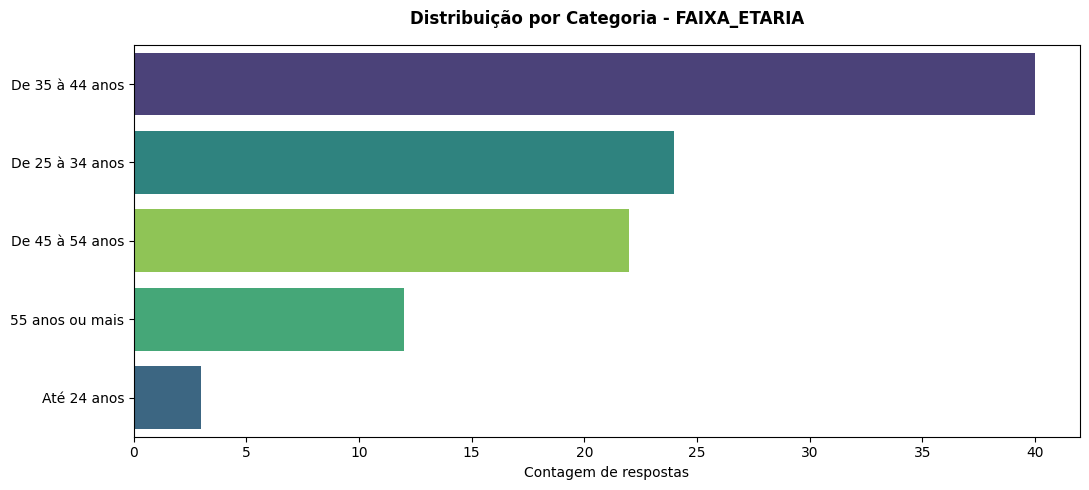

In [23]:
analisar_coluna(df_pesquisa,'FAIXA_ETARIA')

🔄 --- ANÁLISE EM QUADROS (PERCENTUAL % COM RÓTULOS): FAIXA_ETARIA por SETOR_ATUACAO --- 📊

📋 Tabela de Frequência Absoluta (Contagem):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
FAIXA_ETARIA,,
55 anos ou mais,4,8
De 45 à 54 anos,7,15
De 35 à 44 anos,13,27
De 25 à 34 anos,12,12
Até 24 anos,1,2



📈 Tabela Percentual Relativa (Distribuição % por coluna/quadro):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
FAIXA_ETARIA,,
55 anos ou mais,10.8,12.5
De 45 à 54 anos,18.9,23.4
De 35 à 44 anos,35.1,42.2
De 25 à 34 anos,32.4,18.8
Até 24 anos,2.7,3.1



--------------------------------------------------------------------------------



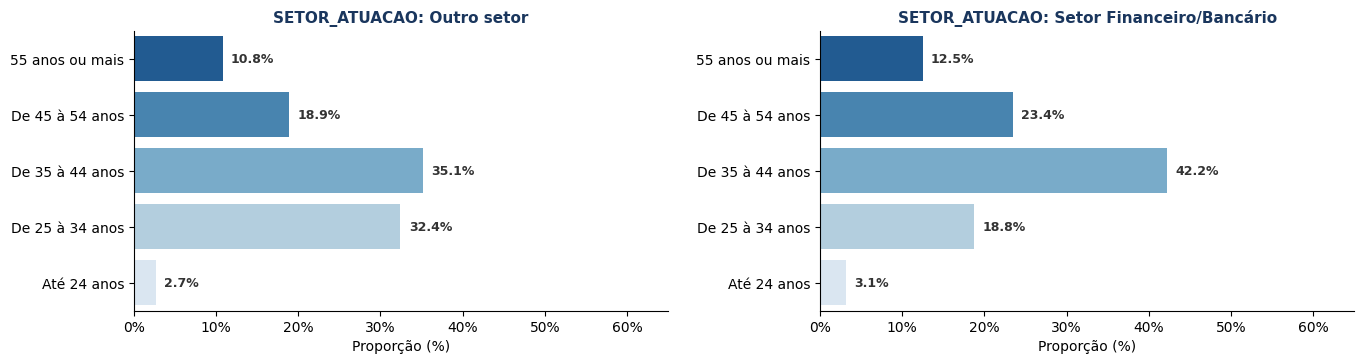

In [24]:
analisar_cruzamento_separado_pct(df_pesquisa,'FAIXA_ETARIA','SETOR_ATUACAO',ordem_idade)

🔄 --- ANÁLISE EM QUADROS (PERCENTUAL % COM RÓTULOS): NIVEL_ACADEMICO por SETOR_ATUACAO --- 📊

📋 Tabela de Frequência Absoluta (Contagem):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
NIVEL_ACADEMICO,,
Doutorado,1.0,0.0
Mestrado,3.0,7.0
"Especialização (Pós-graduação lato sensu, MBA)",21.0,34.0
"Graduação (Bacharelado, Licenciatura ou Tecnólogo)",12.0,22.0
Ensino médio / Técnico / Profissionalizante,0.0,1.0
Ensino fundamental ou menos,NaN,NaN



📈 Tabela Percentual Relativa (Distribuição % por coluna/quadro):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
NIVEL_ACADEMICO,,
Doutorado,2.7,0.0
Mestrado,8.1,10.9
"Especialização (Pós-graduação lato sensu, MBA)",56.8,53.1
"Graduação (Bacharelado, Licenciatura ou Tecnólogo)",32.4,34.4
Ensino médio / Técnico / Profissionalizante,0.0,1.6
Ensino fundamental ou menos,NaN,NaN



--------------------------------------------------------------------------------



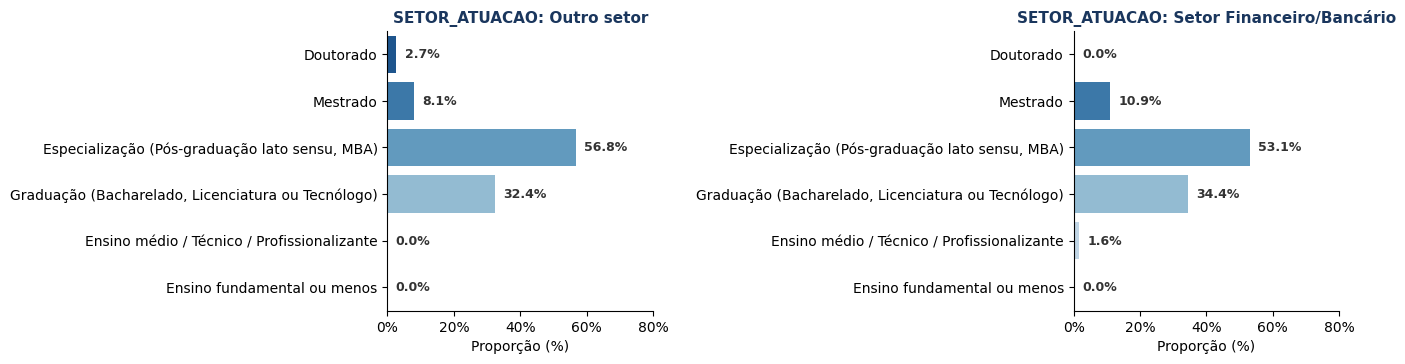

In [25]:
analisar_cruzamento_separado_pct(df_pesquisa,'NIVEL_ACADEMICO','SETOR_ATUACAO',ordem_nvl_academico)

🔄 --- ANÁLISE EM QUADROS (PERCENTUAL % COM RÓTULOS): TEMPO_ATUACAO por SETOR_ATUACAO --- 📊

📋 Tabela de Frequência Absoluta (Contagem):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
TEMPO_ATUACAO,,
Acima de 5 anos,26,46
Entre 1 e 5 anos,9,14
Até 1 ano de atuação,2,4



📈 Tabela Percentual Relativa (Distribuição % por coluna/quadro):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
TEMPO_ATUACAO,,
Acima de 5 anos,70.3,71.9
Entre 1 e 5 anos,24.3,21.9
Até 1 ano de atuação,5.4,6.2



--------------------------------------------------------------------------------



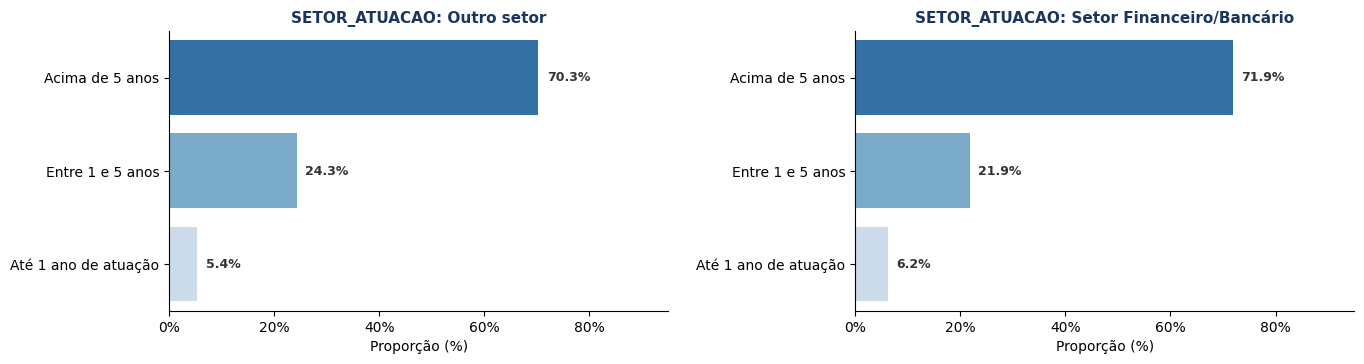

In [26]:
analisar_cruzamento_separado_pct(df_pesquisa,'TEMPO_ATUACAO','SETOR_ATUACAO',ordem_tempo_atuacao)

🔄 --- ANÁLISE EM QUADROS (PERCENTUAL % COM RÓTULOS): NIVEL_HIERARQUICO por SETOR_ATUACAO --- 📊

📋 Tabela de Frequência Absoluta (Contagem):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
NIVEL_HIERARQUICO,,
"Gestor (Superintendente, gerente, supervisor, coordenador)",6,7
Analista/Especialista/Técnico,23,50
Operacional,4,5
Outro,4,2



📈 Tabela Percentual Relativa (Distribuição % por coluna/quadro):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
NIVEL_HIERARQUICO,,
"Gestor (Superintendente, gerente, supervisor, coordenador)",16.2,10.9
Analista/Especialista/Técnico,62.2,78.1
Operacional,10.8,7.8
Outro,10.8,3.1



--------------------------------------------------------------------------------



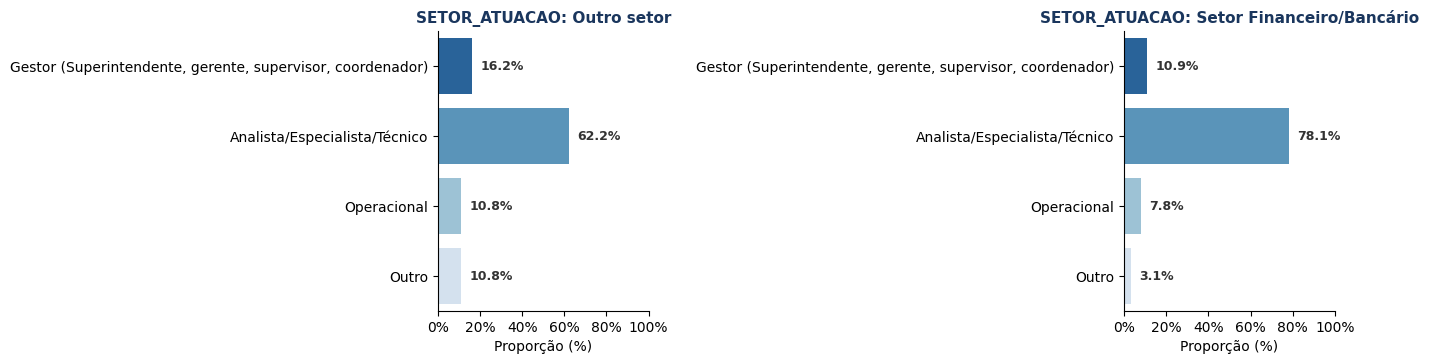

In [27]:
analisar_cruzamento_separado_pct(df_pesquisa,'NIVEL_HIERARQUICO','SETOR_ATUACAO',ordem_nvl_hierarquico)

In [28]:
# Corrigir erro de digitação na coluna categórica
df_pesquisa["AREA_ATUACAO_ORG"] = df_pesquisa["AREA_ATUACAO_ORG"].replace(
    "Tecnologia da Inoformação/ Desenvolvimento",
    "Tecnologia da Informação/ Desenvolvimento"
)

🔄 --- ANÁLISE EM QUADROS (PERCENTUAL % COM RÓTULOS): AREA_ATUACAO_ORG por SETOR_ATUACAO --- 📊

📋 Tabela de Frequência Absoluta (Contagem):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
AREA_ATUACAO_ORG,,
Tecnologia da Informação/ Desenvolvimento,20,28
Área de negócio / administrativa,9,24
Área operacional/ atendimento interno e/ou externo,8,12



📈 Tabela Percentual Relativa (Distribuição % por coluna/quadro):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
AREA_ATUACAO_ORG,,
Tecnologia da Informação/ Desenvolvimento,54.1,43.8
Área de negócio / administrativa,24.3,37.5
Área operacional/ atendimento interno e/ou externo,21.6,18.8



--------------------------------------------------------------------------------



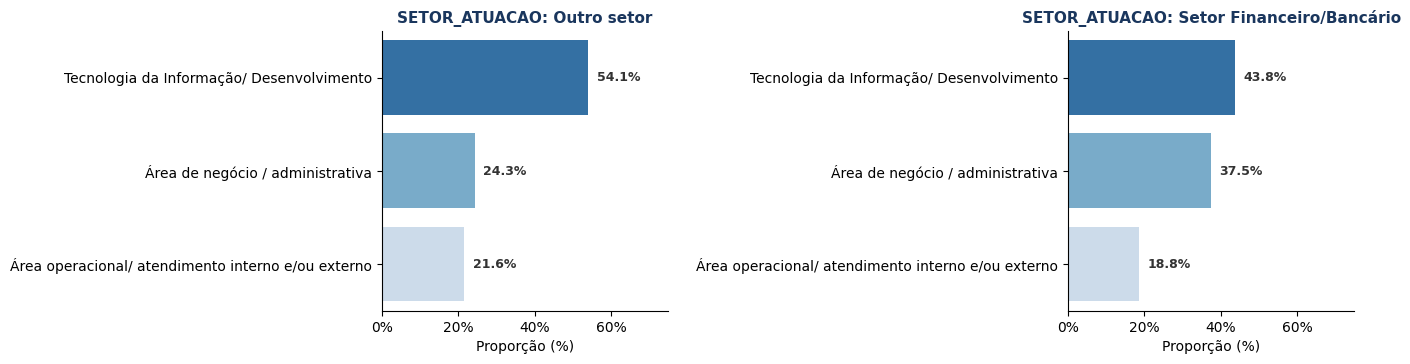

In [29]:
analisar_cruzamento_separado_pct(df_pesquisa,'AREA_ATUACAO_ORG','SETOR_ATUACAO')

In [30]:
ordem_perfil_formacao = [
    "Exclusivamente TI",
    "TI e Negócios/Finanças",
    "Exclusivamente Finanças/Negócios",
    "Outras Formações",
]

🔄 --- ANÁLISE EM QUADROS (PERCENTUAL % COM RÓTULOS): PERFIL_FORMACAO por SETOR_ATUACAO --- 📊

📋 Tabela de Frequência Absoluta (Contagem):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
PERFIL_FORMACAO,,
Exclusivamente TI,20,23
TI e Negócios/Finanças,3,3
Exclusivamente Finanças/Negócios,6,25
Outras Formações,8,13



📈 Tabela Percentual Relativa (Distribuição % por coluna/quadro):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
PERFIL_FORMACAO,,
Exclusivamente TI,54.1,35.9
TI e Negócios/Finanças,8.1,4.7
Exclusivamente Finanças/Negócios,16.2,39.1
Outras Formações,21.6,20.3



--------------------------------------------------------------------------------



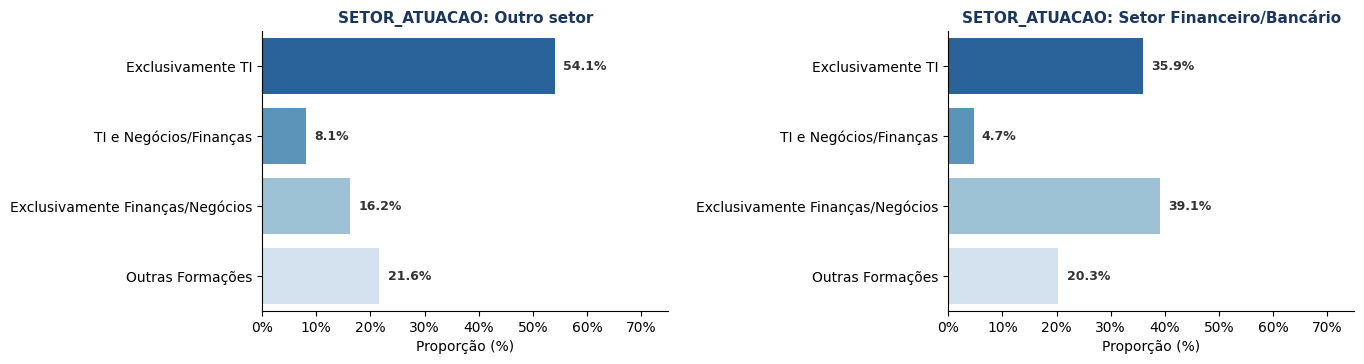

In [31]:
analisar_cruzamento_separado_pct(df_pesquisa,'PERFIL_FORMACAO','SETOR_ATUACAO',ordem_perfil_formacao)

In [32]:
condicoes = [
    (df_pesquisa['DOMINIO_METODOLOGIAS_AGEIS_1A10'] >= 9),
    (df_pesquisa['DOMINIO_METODOLOGIAS_AGEIS_1A10'] >= 7) & (df_pesquisa['DOMINIO_METODOLOGIAS_AGEIS_1A10'] <= 8),
    (df_pesquisa['DOMINIO_METODOLOGIAS_AGEIS_1A10'] >= 5) & (df_pesquisa['DOMINIO_METODOLOGIAS_AGEIS_1A10'] <= 6),
    (df_pesquisa['DOMINIO_METODOLOGIAS_AGEIS_1A10'] >= 1) & (df_pesquisa['DOMINIO_METODOLOGIAS_AGEIS_1A10'] <= 4)
]

rotulos = [
    "Avançado / Especialista (Notas 9-10)",
    "Intermediário (Notas 7-8)",
    "Básico / Iniciante (Notas 5-6)",
    "Pouco ou Nenhum Conhecimento (Notas 1-4)"
]


df_pesquisa['NIVEL_DOMINIO_AGIL'] = np.select(condicoes, rotulos, default="Não informado")

In [33]:
ordem_dominio_agil = [
    "Avançado / Especialista (Notas 9-10)",
    "Intermediário (Notas 7-8)",
    "Básico / Iniciante (Notas 5-6)",
    "Pouco ou Nenhum Conhecimento (Notas 1-4)",
    "Não informado"
]

In [34]:
df_pesquisa['NIVEL_DOMINIO_AGIL']

,NIVEL_DOMINIO_AGIL
0,Intermediário (Notas 7-8)
1,Básico / Iniciante (Notas 5-6)
2,Básico / Iniciante (Notas 5-6)
4,Pouco ou Nenhum Conhecimento (Notas 1-4)
5,Pouco ou Nenhum Conhecimento (Notas 1-4)
...,...
105,Básico / Iniciante (Notas 5-6)
106,Não informado
107,Intermediário (Notas 7-8)
108,Não informado


🔄 --- ANÁLISE EM QUADROS (PERCENTUAL % COM RÓTULOS): ADOTA_PRATICAS_AGEIS_NA_AREA por SETOR_ATUACAO --- 📊

📋 Tabela de Frequência Absoluta (Contagem):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
ADOTA_PRATICAS_AGEIS_NA_AREA,,
Não,9,12
Não sei informar,0,4
"Sim, de forma pontual",13,15
"Sim, de forma recorrente",15,33



📈 Tabela Percentual Relativa (Distribuição % por coluna/quadro):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
ADOTA_PRATICAS_AGEIS_NA_AREA,,
Não,24.3,18.8
Não sei informar,0.0,6.2
"Sim, de forma pontual",35.1,23.4
"Sim, de forma recorrente",40.5,51.6



--------------------------------------------------------------------------------



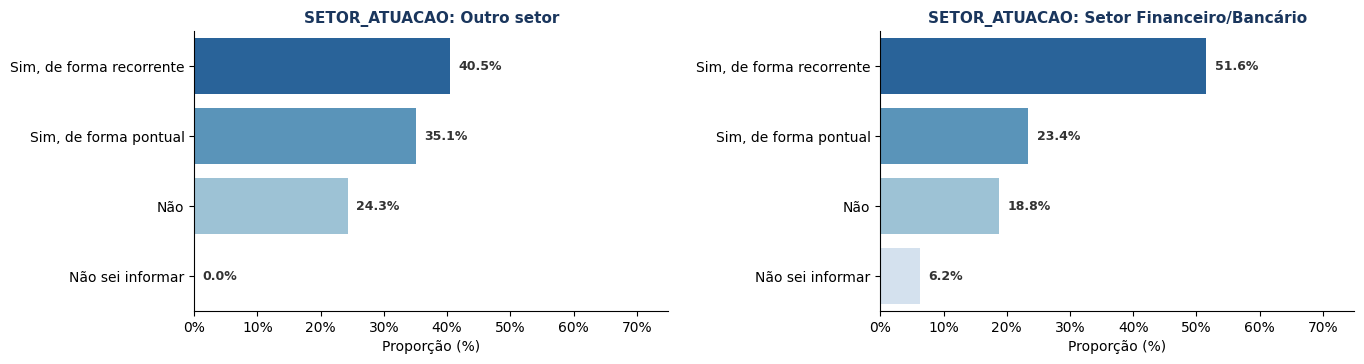

In [35]:
analisar_cruzamento_separado_pct(df_pesquisa,'ADOTA_PRATICAS_AGEIS_NA_AREA','SETOR_ATUACAO',)

🔄 --- ANÁLISE EM QUADROS (PERCENTUAL % COM RÓTULOS): NIVEL_DOMINIO_AGIL por SETOR_ATUACAO --- 📊

📋 Tabela de Frequência Absoluta (Contagem):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
NIVEL_DOMINIO_AGIL,,
Avançado / Especialista (Notas 9-10),8,5
Intermediário (Notas 7-8),10,29
Básico / Iniciante (Notas 5-6),11,14
Pouco ou Nenhum Conhecimento (Notas 1-4),4,10
Não informado,4,6



📈 Tabela Percentual Relativa (Distribuição % por coluna/quadro):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
NIVEL_DOMINIO_AGIL,,
Avançado / Especialista (Notas 9-10),21.6,7.8
Intermediário (Notas 7-8),27.0,45.3
Básico / Iniciante (Notas 5-6),29.7,21.9
Pouco ou Nenhum Conhecimento (Notas 1-4),10.8,15.6
Não informado,10.8,9.4



--------------------------------------------------------------------------------



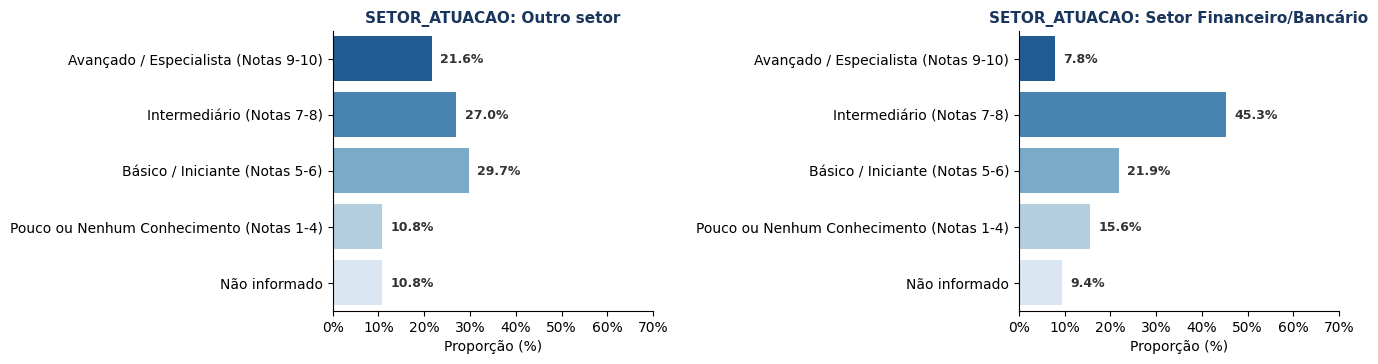

In [36]:
analisar_cruzamento_separado_pct(df_pesquisa,'NIVEL_DOMINIO_AGIL','SETOR_ATUACAO',ordem_dominio_agil)

In [37]:
df_pesquisa['NIVEL_DOMINIO_AGIL']

,NIVEL_DOMINIO_AGIL
0,Intermediário (Notas 7-8)
1,Básico / Iniciante (Notas 5-6)
2,Básico / Iniciante (Notas 5-6)
4,Pouco ou Nenhum Conhecimento (Notas 1-4)
5,Pouco ou Nenhum Conhecimento (Notas 1-4)
...,...
105,Básico / Iniciante (Notas 5-6)
106,Não informado
107,Intermediário (Notas 7-8)
108,Não informado


🔄 --- ANÁLISE EM QUADROS (PERCENTUAL % COM RÓTULOS): POSSUI_CERTIFICACAO_AGIL por SETOR_ATUACAO --- 📊

📋 Tabela de Frequência Absoluta (Contagem):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
POSSUI_CERTIFICACAO_AGIL,,
Não,33,60
Sim,4,4



📈 Tabela Percentual Relativa (Distribuição % por coluna/quadro):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
POSSUI_CERTIFICACAO_AGIL,,
Não,89.2,93.8
Sim,10.8,6.2



--------------------------------------------------------------------------------



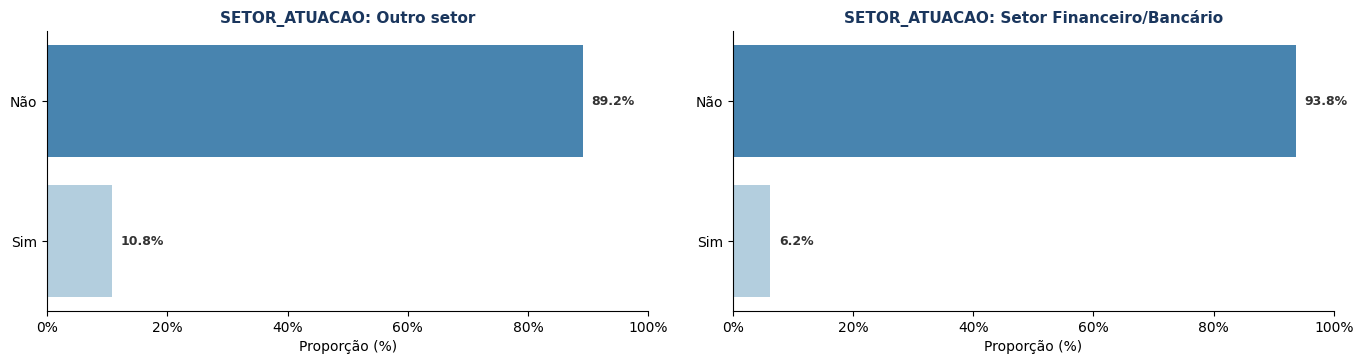

In [38]:
analisar_cruzamento_separado_pct(df_pesquisa,'POSSUI_CERTIFICACAO_AGIL','SETOR_ATUACAO')

In [39]:
ordem_tempo_agil = [
    'Mais de 20 horas',
    'Entre 10 e 20 horas',
    'Entre 5 e 10 horas',
    'Entre 2 e 5 horas',
    'Entre 1 e 2 horas',
    'Entre 31 e 60 min',
    'Até 30 min',
    'Não sei informar',
]

🔄 --- ANÁLISE EM QUADROS (PERCENTUAL % COM RÓTULOS): TEMPO_SEMANAL_CERIMONIAS por SETOR_ATUACAO --- 📊

📋 Tabela de Frequência Absoluta (Contagem):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
TEMPO_SEMANAL_CERIMONIAS,,
Mais de 20 horas,NaN,NaN
Entre 10 e 20 horas,NaN,NaN
Entre 5 e 10 horas,5.0,3.0
Entre 2 e 5 horas,2.0,17.0
Entre 1 e 2 horas,8.0,11.0
Entre 31 e 60 min,7.0,9.0
Até 30 min,6.0,6.0
Não sei informar,0.0,2.0



📈 Tabela Percentual Relativa (Distribuição % por coluna/quadro):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
TEMPO_SEMANAL_CERIMONIAS,,
Mais de 20 horas,NaN,NaN
Entre 10 e 20 horas,NaN,NaN
Entre 5 e 10 horas,17.9,6.2
Entre 2 e 5 horas,7.1,35.4
Entre 1 e 2 horas,28.6,22.9
Entre 31 e 60 min,25.0,18.8
Até 30 min,21.4,12.5
Não sei informar,0.0,4.2



--------------------------------------------------------------------------------



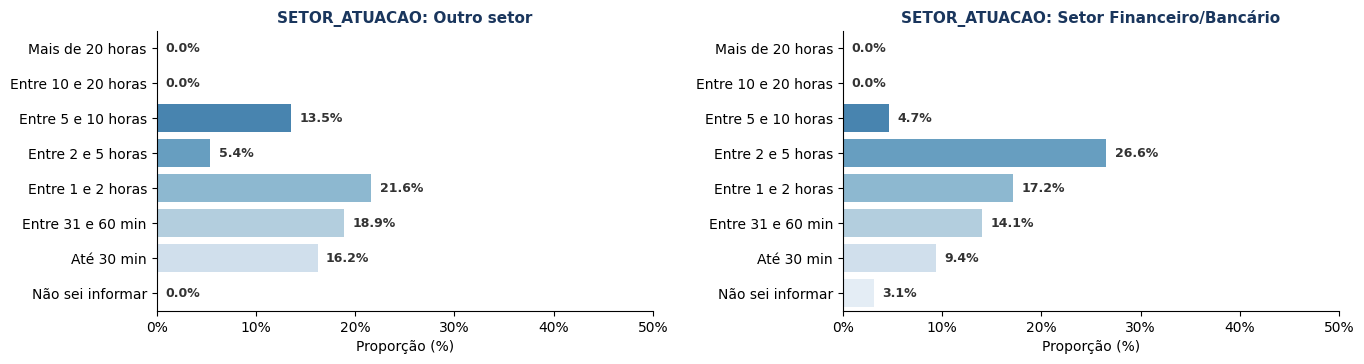

In [40]:
analisar_cruzamento_separado_pct(df_pesquisa,'TEMPO_SEMANAL_CERIMONIAS','SETOR_ATUACAO',ordem_tempo_agil)

In [41]:
df_pesquisa['TEMPO_SEMANAL_CERIMONIAS'] = (
    df_pesquisa['TEMPO_SEMANAL_CERIMONIAS']
    .replace(r'^\s*$', np.nan, regex=True)
    .fillna('Não sei informar')
)

🔄 --- ANÁLISE EM QUADROS (PERCENTUAL % COM RÓTULOS): TEMPO_SEMANAL_CERIMONIAS por SETOR_ATUACAO --- 📊

📋 Tabela de Frequência Absoluta (Contagem):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
TEMPO_SEMANAL_CERIMONIAS,,
Mais de 20 horas,NaN,NaN
Entre 10 e 20 horas,NaN,NaN
Entre 5 e 10 horas,5.0,3.0
Entre 2 e 5 horas,2.0,17.0
Entre 1 e 2 horas,8.0,11.0
Entre 31 e 60 min,7.0,9.0
Até 30 min,6.0,6.0
Não sei informar,9.0,18.0



📈 Tabela Percentual Relativa (Distribuição % por coluna/quadro):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
TEMPO_SEMANAL_CERIMONIAS,,
Mais de 20 horas,NaN,NaN
Entre 10 e 20 horas,NaN,NaN
Entre 5 e 10 horas,13.5,4.7
Entre 2 e 5 horas,5.4,26.6
Entre 1 e 2 horas,21.6,17.2
Entre 31 e 60 min,18.9,14.1
Até 30 min,16.2,9.4
Não sei informar,24.3,28.1



--------------------------------------------------------------------------------



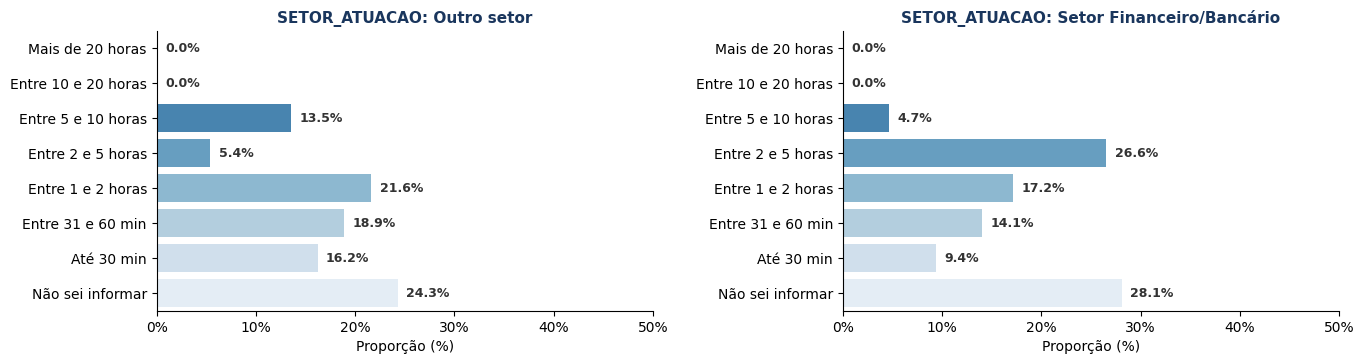

In [42]:
analisar_cruzamento_separado_pct(df_pesquisa,'TEMPO_SEMANAL_CERIMONIAS','SETOR_ATUACAO',ordem_tempo_agil)

🔄 --- ANÁLISE EM QUADROS (PERCENTUAL % COM RÓTULOS): QUAIS_PRATICAS_AGEIS_ADOTADAS por SETOR_ATUACAO --- 📊

📋 Tabela de Frequência Absoluta (Contagem):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
QUAIS_PRATICAS_AGEIS_ADOTADAS,,
Planejamento periódico/semanal;,0,3
Planejamento periódico/semanal;Retrospectivas;,0,1
Planejamento periódico/semanal;Reuniões de acompanhamento;,0,3
Planejamento periódico/semanal;Reuniões de acompanhamento;Revisões de entregas;,2,2
Planejamento periódico/semanal;Reuniões de acompanhamento;Revisões de entregas;Retrospectivas;,1,0
Planejamento periódico/semanal;Revisões de entregas;,1,2
Retrospectivas;Revisões de entregas;Reuniões de acompanhamento;Planejamento periódico/semanal;,1,0
Reuniões de acompanhamento;,4,3
Reuniões diárias (Daily);,1,0



📈 Tabela Percentual Relativa (Distribuição % por coluna/quadro):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
QUAIS_PRATICAS_AGEIS_ADOTADAS,,
Planejamento periódico/semanal;,0.0,6.2
Planejamento periódico/semanal;Retrospectivas;,0.0,2.1
Planejamento periódico/semanal;Reuniões de acompanhamento;,0.0,6.2
Planejamento periódico/semanal;Reuniões de acompanhamento;Revisões de entregas;,7.1,4.2
Planejamento periódico/semanal;Reuniões de acompanhamento;Revisões de entregas;Retrospectivas;,3.6,0.0
Planejamento periódico/semanal;Revisões de entregas;,3.6,4.2
Retrospectivas;Revisões de entregas;Reuniões de acompanhamento;Planejamento periódico/semanal;,3.6,0.0
Reuniões de acompanhamento;,14.3,6.2
Reuniões diárias (Daily);,3.6,0.0



--------------------------------------------------------------------------------



/tmp/ipykernel_24379/2122554281.py:108: UserWarning: Tight layout not applied. tight_layout cannot make Axes width small enough to accommodate all Axes decorations
  plt.tight_layout(pad=2.0)


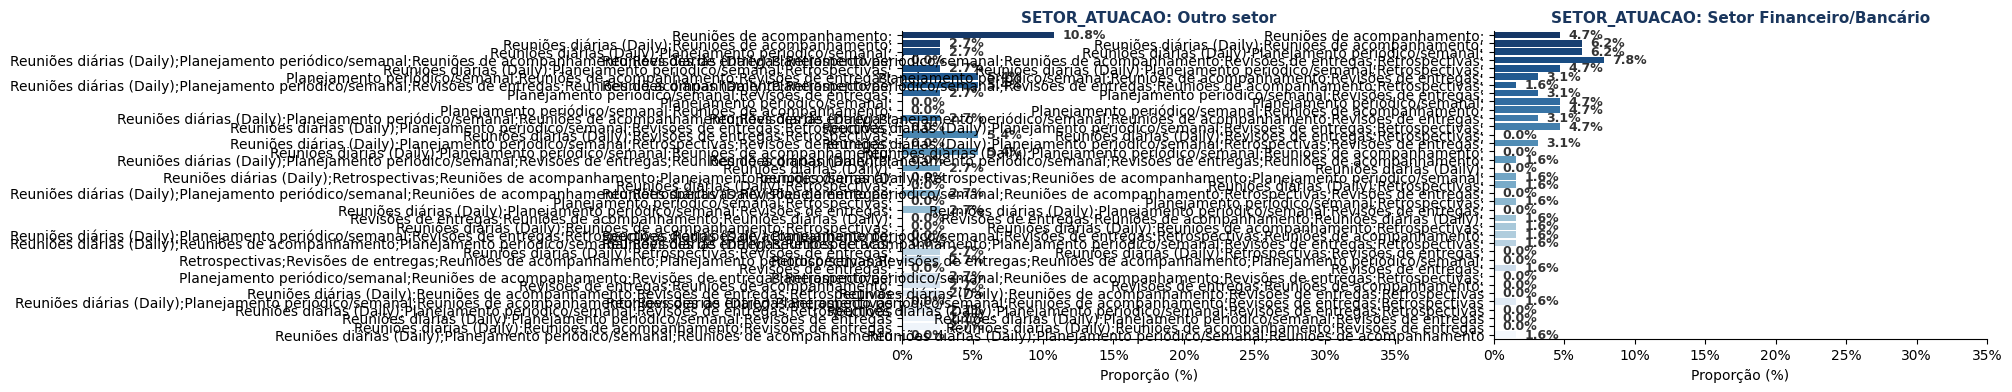

In [43]:
analisar_cruzamento_separado_pct(df_pesquisa,'QUAIS_PRATICAS_AGEIS_ADOTADAS','SETOR_ATUACAO')

In [44]:
# 0. Ajuste o nome da coluna conforme sua planilha
coluna_praticas = 'QUAIS_PRATICAS_AGEIS_ADOTADAS'

# 1. Cria marcadores booleanos temporários para identificar a presença de cada rito chave
tem_daily = df_pesquisa[coluna_praticas].str.contains('Daily', na=False)
tem_planning = df_pesquisa[coluna_praticas].str.contains('Planejamento', na=False)
tem_review = df_pesquisa[coluna_praticas].str.contains('Revis', na=False)
tem_retro = df_pesquisa[coluna_praticas].str.contains('Retrospectiva', na=False)
#tem_refinamento = df_pesquisa[coluna_praticas].str.contains('Refinamento do backlog', na=False)
tem_quadro = df_pesquisa[coluna_praticas].str.contains('acompanhamento', na=False)

# Somador de ritos de reuniões clássicas (Máximo 4)
total_ritos_scrum = tem_daily.astype(int) + tem_planning.astype(int) + tem_review.astype(int) + tem_retro.astype(int)

# 2. Estabelece as regras de hierarquia de agrupamento
condicoes = [
    (total_ritos_scrum == 4),                             # Regra 1: Framework Scrum em sua totalidade
    (total_ritos_scrum > 2),                              # Regra 2: Cadência forte de reuniões Scrum
    (tem_daily & tem_quadro) & (total_ritos_scrum == 2),  # Regra 3: Daily + Quadro + mais um rito
    (tem_daily) & (total_ritos_scrum == 1),               # Regra 4: Apenas Daily
    (tem_quadro) & (total_ritos_scrum == 1),              # Regra 5: Apenas Quadro
]

# 3. Rótulos simplificados para exibição gráfica profissional
rotulos = [
    "Scrum Completo (4 Ritos)",
    "Scrum Parcial (3 Ritos)",
    "Acompanhamento de atividades e Daily",
    "Alinhamento Diário (Daily)",
    "Acompanhamento de atividades (Eventuais)",
]

ordem_praticas_ageis = [
    "Scrum Completo (4 Ritos)",
    "Scrum Parcial (3 Ritos)",
    "Acompanhamento de atividades e Daily",
    "Alinhamento Diário (Daily)",
    "Acompanhamento de atividades",
    "Práticas Isoladas ou não sabe informar"
]
# 4. Injeta a nova coluna tratada na base. O que não encaixar nas regras vira 'Práticas Isoladas'
df_pesquisa['CATEGORIA_PRATICAS_ADOTADAS'] = np.select(condicoes, rotulos, default="Práticas Isoladas ou não sabe informar")

# 5. Imprime a tabela de conferência limpa para validação
contagem = df_pesquisa['CATEGORIA_PRATICAS_ADOTADAS'].value_counts()
percentual = df_pesquisa['CATEGORIA_PRATICAS_ADOTADAS'].value_counts(normalize=True) * 100

df_dashboard = pd.DataFrame({
    'Quantidade': contagem,
    'Proporção (%)': percentual.round(1)
})

print("✅ Coluna 'CATEGORIA_PRATICAS_ADOTADAS' gerada com sucesso!\n")
display(df_dashboard)

✅ Coluna 'CATEGORIA_PRATICAS_ADOTADAS' gerada com sucesso!



,Quantidade,Proporção (%)
CATEGORIA_PRATICAS_ADOTADAS,,
Práticas Isoladas ou não sabe informar,50,49.5
Scrum Completo (4 Ritos),18,17.8
Scrum Parcial (3 Ritos),17,16.8
Alinhamento Diário (Daily),6,5.9
Acompanhamento de atividades e Daily,6,5.9
Acompanhamento de atividades (Eventuais),4,4.0


In [45]:
df_pesquisa[coluna_praticas].describe()

,QUAIS_PRATICAS_AGEIS_ADOTADAS
count,76
unique,37
top,Reuniões de acompanhamento;
freq,7


🔄 --- ANÁLISE EM QUADROS (PERCENTUAL % COM RÓTULOS): CATEGORIA_PRATICAS_ADOTADAS por SETOR_ATUACAO --- 📊

📋 Tabela de Frequência Absoluta (Contagem):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
CATEGORIA_PRATICAS_ADOTADAS,,
Scrum Completo (4 Ritos),4.0,14.0
Scrum Parcial (3 Ritos),10.0,7.0
Acompanhamento de atividades e Daily,3.0,3.0
Alinhamento Diário (Daily),2.0,4.0
Acompanhamento de atividades,NaN,NaN
Práticas Isoladas ou não sabe informar,17.0,33.0



📈 Tabela Percentual Relativa (Distribuição % por coluna/quadro):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
CATEGORIA_PRATICAS_ADOTADAS,,
Scrum Completo (4 Ritos),10.8,21.9
Scrum Parcial (3 Ritos),27.0,10.9
Acompanhamento de atividades e Daily,8.1,4.7
Alinhamento Diário (Daily),5.4,6.2
Acompanhamento de atividades,NaN,NaN
Práticas Isoladas ou não sabe informar,45.9,51.6



--------------------------------------------------------------------------------



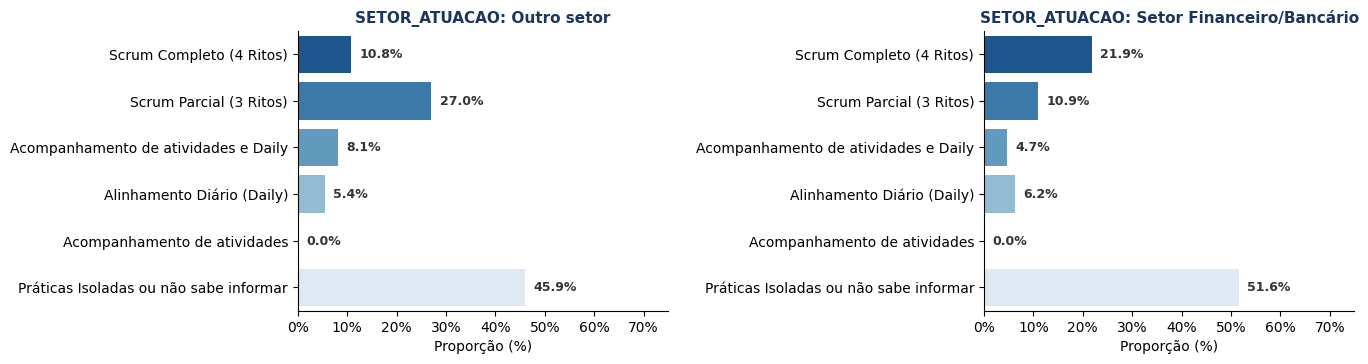

In [46]:
analisar_cruzamento_separado_pct(df_pesquisa,'CATEGORIA_PRATICAS_ADOTADAS','SETOR_ATUACAO',ordem_praticas_ageis)

In [47]:
ordem_configuracao_times = [
    'Squad/time ágil multidisciplinar',
    'Modelo híbrido (mistura de práticas)',
    'Equipe tradicional (processo mais linear/funcional)',
    'Não sei / varia muito'
]

🔄 --- ANÁLISE EM QUADROS (PERCENTUAL % COM RÓTULOS): CONFIGURACAO_ATUACAO por SETOR_ATUACAO --- 📊

📋 Tabela de Frequência Absoluta (Contagem):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
CONFIGURACAO_ATUACAO,,
Squad/time ágil multidisciplinar,5,21
Modelo híbrido (mistura de práticas),14,18
Equipe tradicional (processo mais linear/funcional),7,5
Não sei / varia muito,2,4



📈 Tabela Percentual Relativa (Distribuição % por coluna/quadro):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
CONFIGURACAO_ATUACAO,,
Squad/time ágil multidisciplinar,17.9,43.8
Modelo híbrido (mistura de práticas),50.0,37.5
Equipe tradicional (processo mais linear/funcional),25.0,10.4
Não sei / varia muito,7.1,8.3



--------------------------------------------------------------------------------



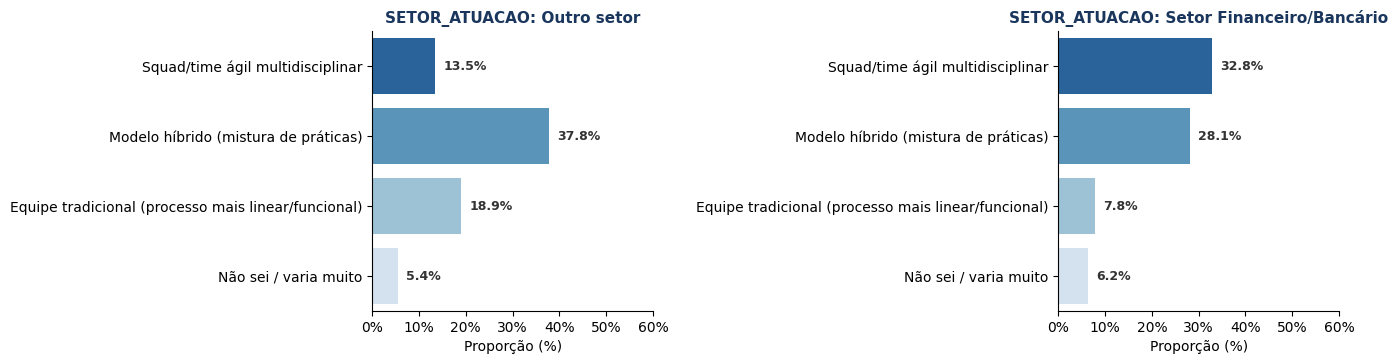

In [48]:
analisar_cruzamento_separado_pct(df_pesquisa,'CONFIGURACAO_ATUACAO','SETOR_ATUACAO',ordem_configuracao_times)

In [49]:
df_pesquisa['CONFIGURACAO_ATUACAO'] = (
    df_pesquisa['CONFIGURACAO_ATUACAO']
    .replace(r'^\s*$', np.nan, regex=True)
    .replace('Não sei / varia muito',
             'Não sei / varia muito / não respondeu')
    .fillna('Não sei / varia muito / não respondeu'))

In [50]:
df_pesquisa['CONFIGURACAO_ATUACAO']

,CONFIGURACAO_ATUACAO
0,Equipe tradicional (processo mais linear/funci...
1,Equipe tradicional (processo mais linear/funci...
2,Modelo híbrido (mistura de práticas)
4,Não sei / varia muito / não respondeu
5,Não sei / varia muito / não respondeu
...,...
105,Equipe tradicional (processo mais linear/funci...
106,Não sei / varia muito / não respondeu
107,Squad/time ágil multidisciplinar
108,Não sei / varia muito / não respondeu


In [51]:
ordem_configuracao_times = [
    'Squad/time ágil multidisciplinar',
    'Modelo híbrido (mistura de práticas)',
    'Equipe tradicional (processo mais linear/funcional)',
    'Não sei / varia muito / não respondeu'
]

🔄 --- ANÁLISE EM QUADROS (PERCENTUAL % COM RÓTULOS): CONFIGURACAO_ATUACAO por SETOR_ATUACAO --- 📊

📋 Tabela de Frequência Absoluta (Contagem):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
CONFIGURACAO_ATUACAO,,
Squad/time ágil multidisciplinar,5,21
Modelo híbrido (mistura de práticas),14,18
Equipe tradicional (processo mais linear/funcional),7,5
Não sei / varia muito / não respondeu,11,20



📈 Tabela Percentual Relativa (Distribuição % por coluna/quadro):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
CONFIGURACAO_ATUACAO,,
Squad/time ágil multidisciplinar,13.5,32.8
Modelo híbrido (mistura de práticas),37.8,28.1
Equipe tradicional (processo mais linear/funcional),18.9,7.8
Não sei / varia muito / não respondeu,29.7,31.2



--------------------------------------------------------------------------------



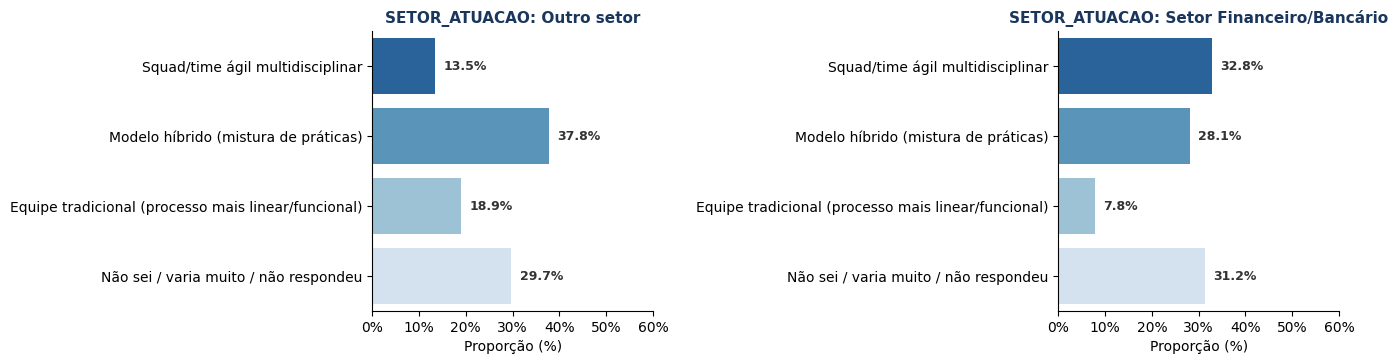

In [52]:
analisar_cruzamento_separado_pct(df_pesquisa,'CONFIGURACAO_ATUACAO','SETOR_ATUACAO',ordem_configuracao_times)

📊 --- PAINEL COMPARATIVO MULTIVARIÁVEL: ÂNCORA [Maturidade no Uso de Práticas Ágeis?] --- 📊



/tmp/ipykernel_24379/370026146.py:66: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


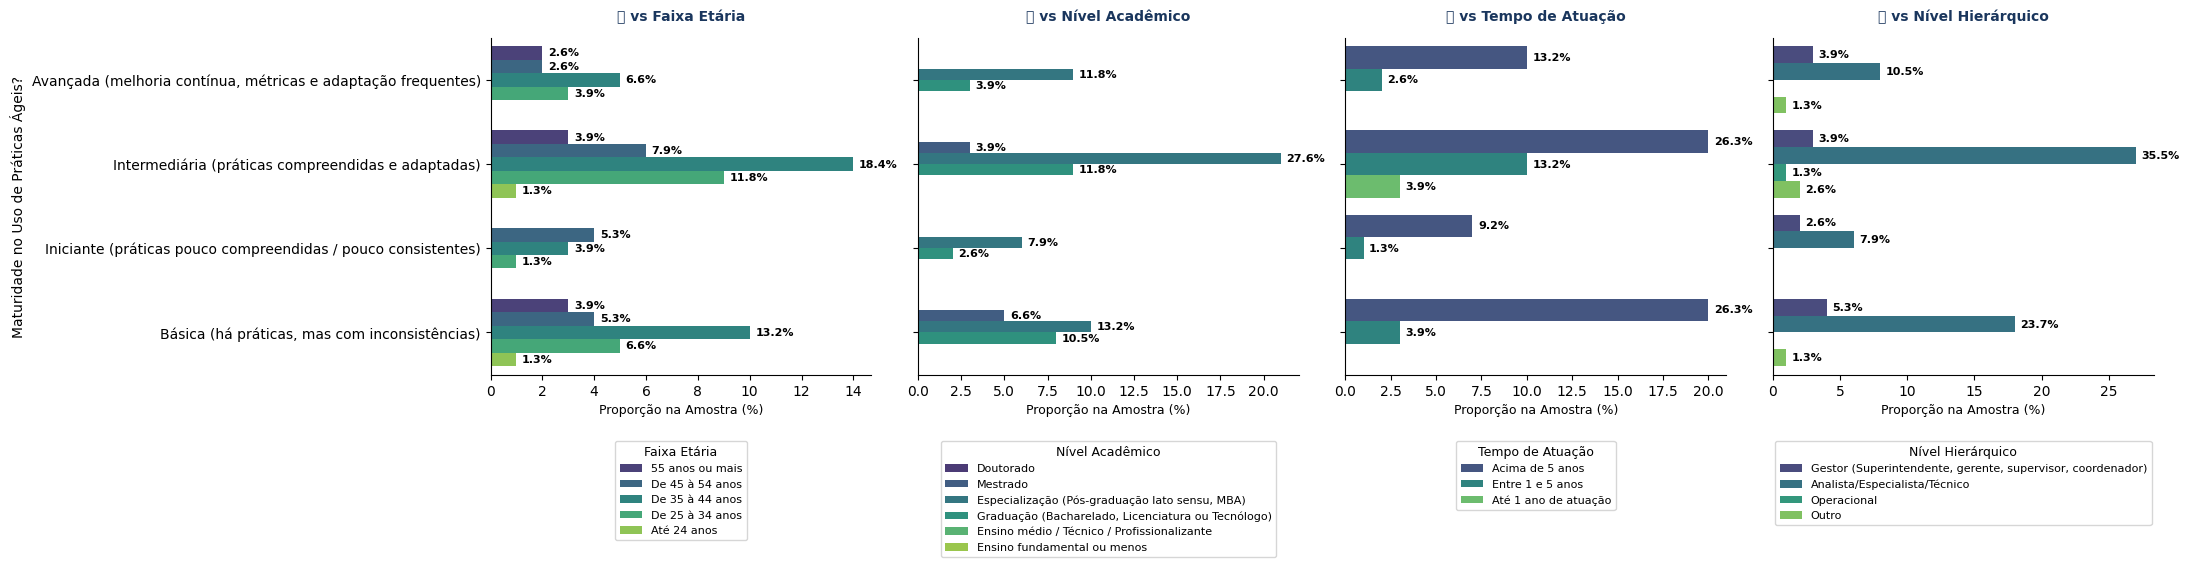

In [53]:
# Seu dicionário com as perguntas ou rótulos ideais para o documento
meu_dicionario_labels = {
    "MATURIDADE_USO_PRATICAS_AGEIS": "Maturidade no Uso de Práticas Ágeis?",
    "FAIXA_ETARIA": "Faixa Etária",
    "NIVEL_ACADEMICO": "Nível Acadêmico",
    "TEMPO_ATUACAO": "Tempo de Atuação",
    "NIVEL_HIERARQUICO": "Nível Hierárquico"
}

# Suas listas de ordens salvas na memória
dicionario_de_ordens = {
    "FAIXA_ETARIA": ordem_idade,
    "NIVEL_ACADEMICO": ordem_nvl_academico,
    "TEMPO_ATUACAO": ordem_tempo_atuacao,
    "NIVEL_HIERARQUICO": ordem_nvl_hierarquico,
    "MATURIDADE_USO_PRATICAS_AGEIS": ordem_maturidade  # Injeção da ordem da maturidade
}

# Suas variáveis de comparação
variaveis_perfil = ["FAIXA_ETARIA", "NIVEL_ACADEMICO", "TEMPO_ATUACAO", "NIVEL_HIERARQUICO"]

# Executa o painel unificado original com as labels configuradas
gerar_painel_comparativo_labels(
    df=df_pesquisa,
    variavel_ancora="MATURIDADE_USO_PRATICAS_AGEIS",
    lista_variaveis_comparar=variaveis_perfil,
    ordens_dicionario=dicionario_de_ordens,
    dicionario_labels=meu_dicionario_labels
)

📊 --- PAINEL COMPARATIVO MULTIVARIÁVEL: ÂNCORA [Maturidade no Uso de Práticas Ágeis?] --- 📊



/tmp/ipykernel_24379/370026146.py:66: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


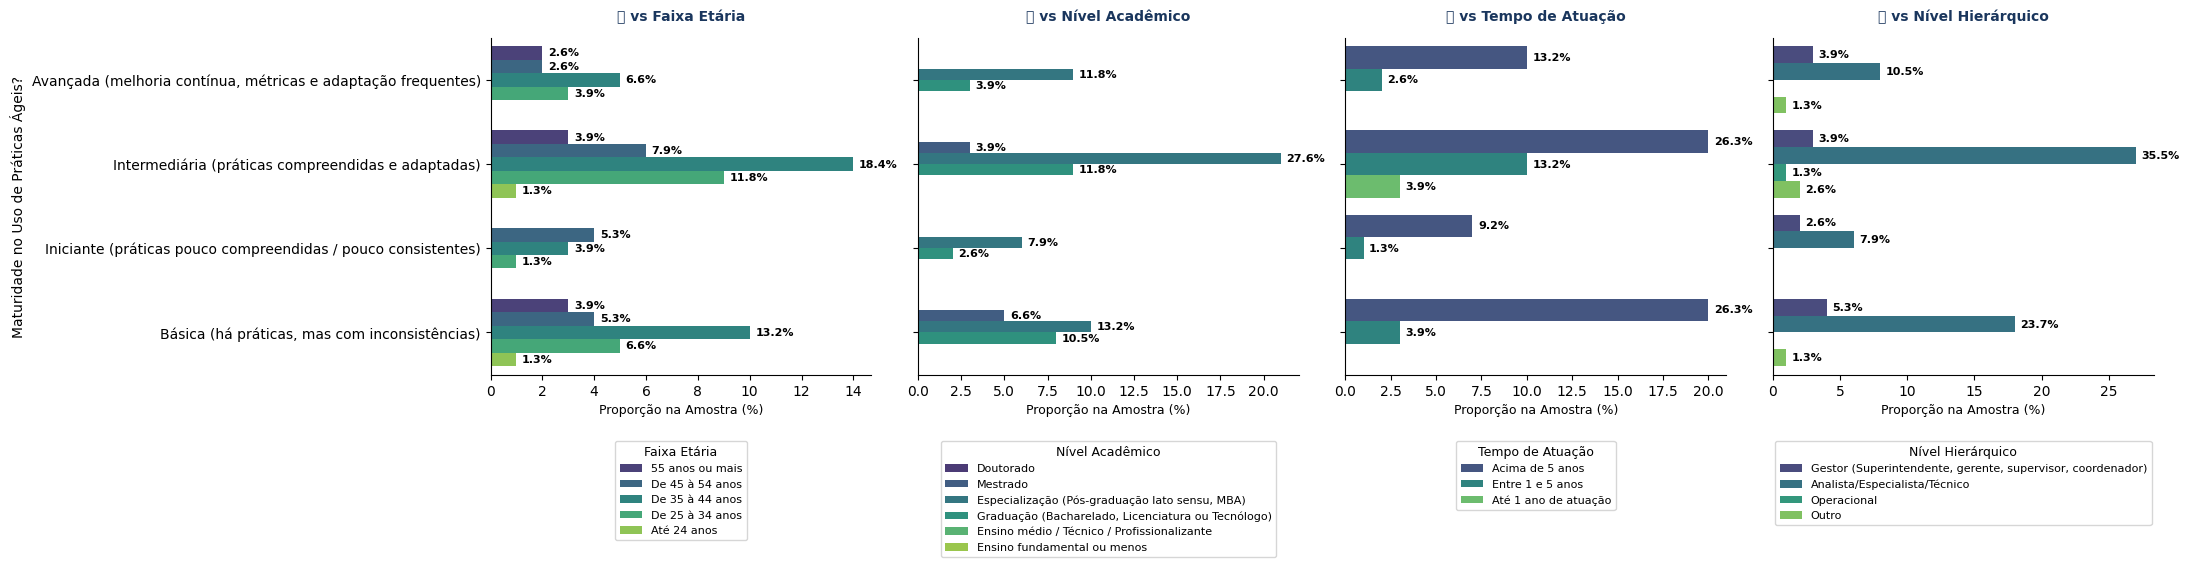

In [54]:
# Suas variáveis de comparação
variaveis_perfil = ["FAIXA_ETARIA", "NIVEL_ACADEMICO", "TEMPO_ATUACAO", "NIVEL_HIERARQUICO"]

# Executa o painel unificado original com as labels configuradas
gerar_painel_comparativo_labels(
    df=df_pesquisa,
    variavel_ancora="MATURIDADE_USO_PRATICAS_AGEIS",
    lista_variaveis_comparar=variaveis_perfil,
    ordens_dicionario=dicionario_de_ordens,
    dicionario_labels=meu_dicionario_labels
)

🏦 ANÁLISE COMPARTIMENTADA: SETOR FINANCEIRO
📊 --- PAINEL COMPARATIVO MULTIVARIÁVEL: ÂNCORA [Maturidade no Uso de Práticas Ágeis? (Setor Bancário)] --- 📊



/tmp/ipykernel_24379/370026146.py:66: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


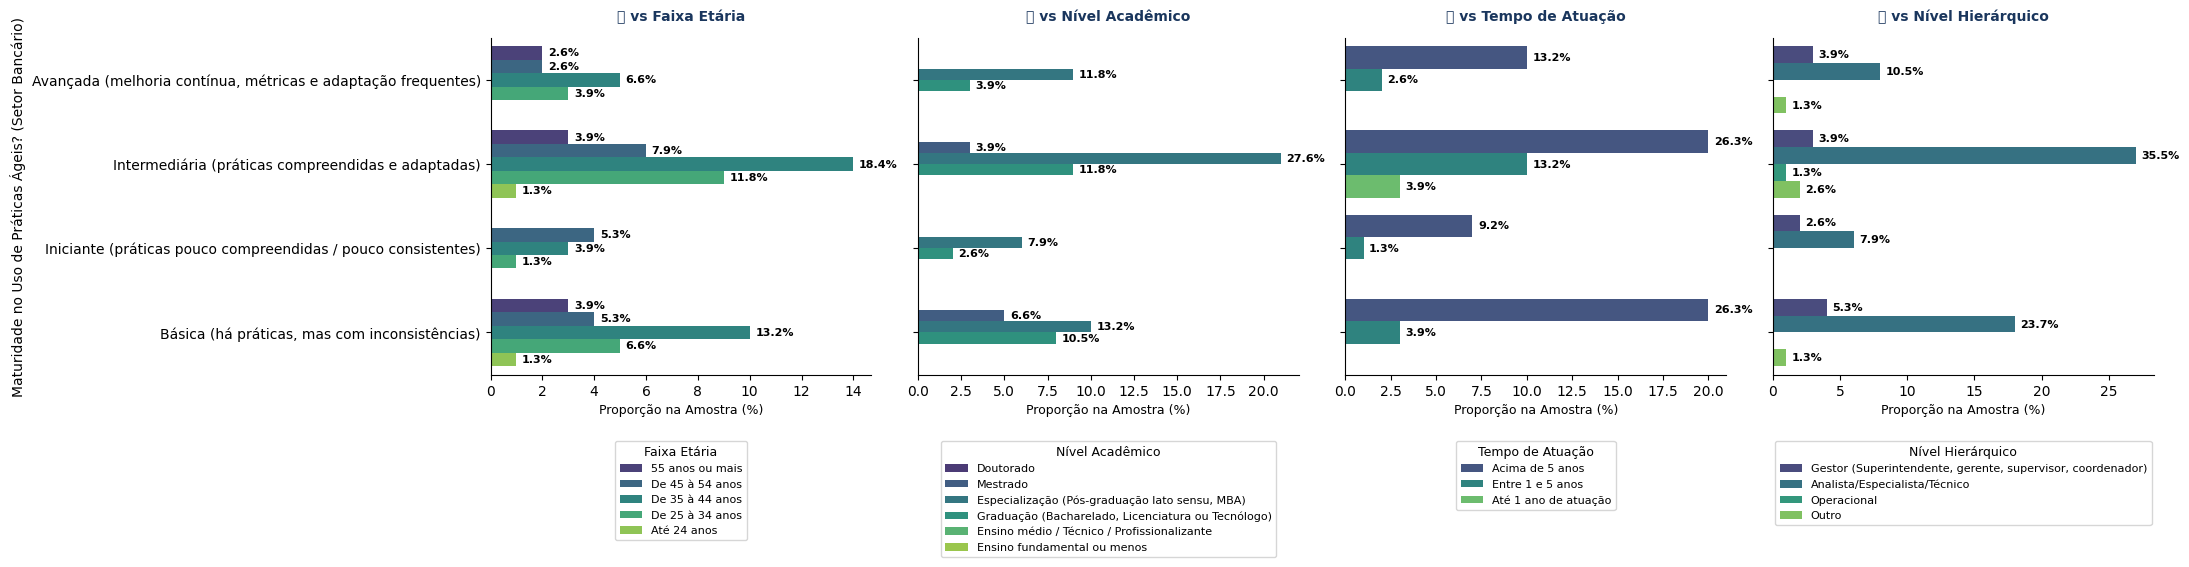

In [55]:
print("🏦 ANÁLISE COMPARTIMENTADA: SETOR FINANCEIRO")
meu_dicionario_labels = {
    "MATURIDADE_USO_PRATICAS_AGEIS": "Maturidade no Uso de Práticas Ágeis? (Setor Bancário)",
    "FAIXA_ETARIA": "Faixa Etária",
    "NIVEL_ACADEMICO": "Nível Acadêmico",
    "TEMPO_ATUACAO": "Tempo de Atuação",
    "NIVEL_HIERARQUICO": "Nível Hierárquico"
}

gerar_painel_comparativo_labels(
    df=df_pesquisa, # <--- Base do banco
    variavel_ancora="MATURIDADE_USO_PRATICAS_AGEIS",
    lista_variaveis_comparar=variaveis_perfil,
    ordens_dicionario=dicionario_de_ordens,
    dicionario_labels=meu_dicionario_labels
)

🚀 ANÁLISE COMPARTIMENTADA: OUTROS SETORES DA AMOSTRA
📊 --- PAINEL COMPARATIVO MULTIVARIÁVEL: ÂNCORA [Maturidade no Uso de Práticas Ágeis? (Demais setores)] --- 📊



/tmp/ipykernel_24379/370026146.py:66: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


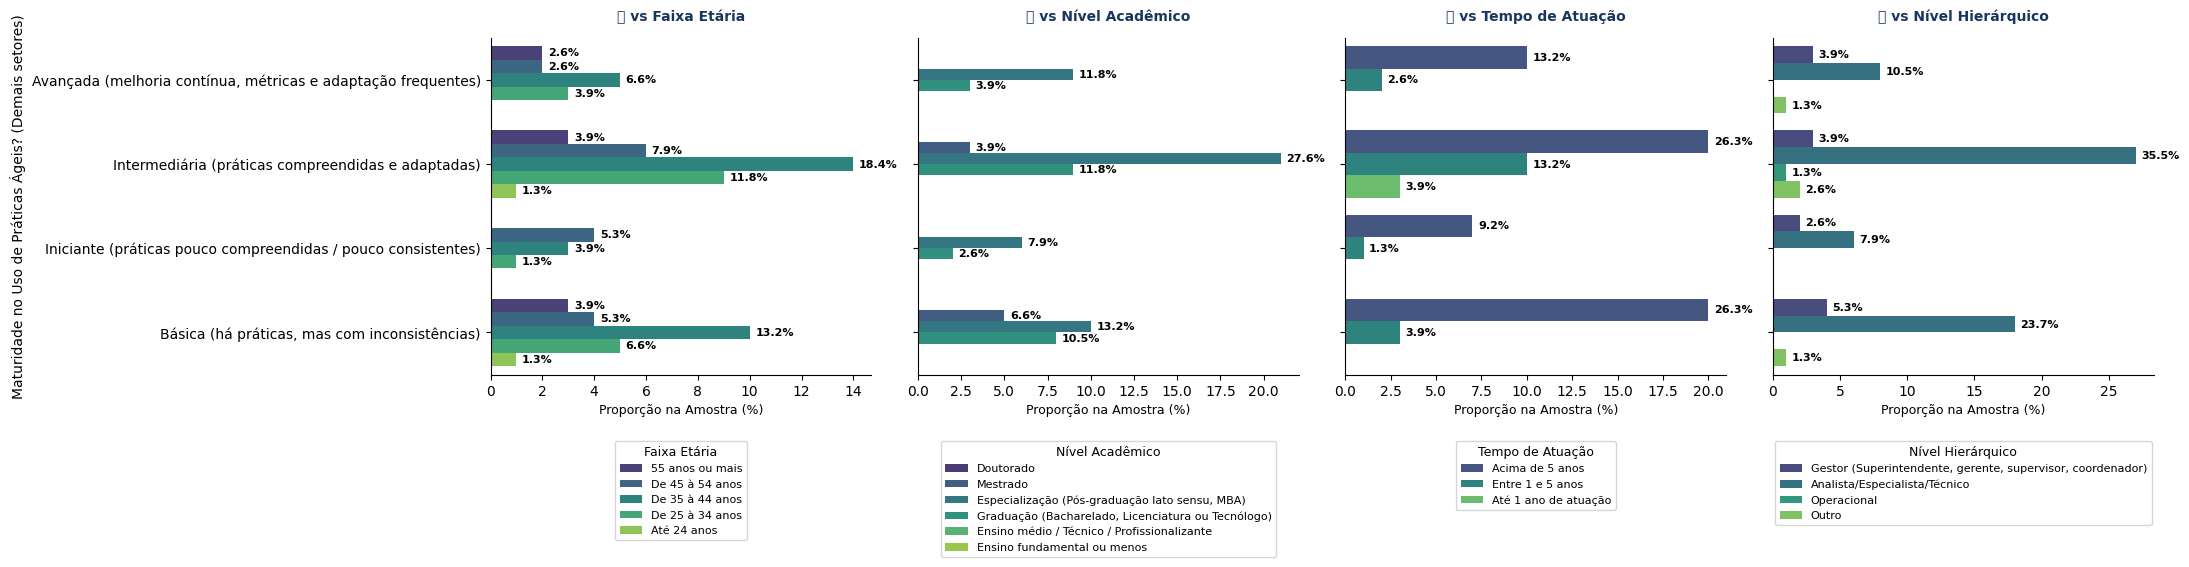

In [56]:
print("🚀 ANÁLISE COMPARTIMENTADA: OUTROS SETORES DA AMOSTRA")

meu_dicionario_labels = {
    "MATURIDADE_USO_PRATICAS_AGEIS": "Maturidade no Uso de Práticas Ágeis? (Demais setores)",
    "FAIXA_ETARIA": "Faixa Etária",
    "NIVEL_ACADEMICO": "Nível Acadêmico",
    "TEMPO_ATUACAO": "Tempo de Atuação",
    "NIVEL_HIERARQUICO": "Nível Hierárquico"
}

gerar_painel_comparativo_labels(
    df=df_pesquisa, # <--- Base do resto do mercado
    variavel_ancora="MATURIDADE_USO_PRATICAS_AGEIS",
    lista_variaveis_comparar=variaveis_perfil,
    ordens_dicionario=dicionario_de_ordens,
    dicionario_labels=meu_dicionario_labels
)

📊 --- PAINEL COMPARATIVO MULTIVARIÁVEL: ÂNCORA [Maturidade no Uso de Práticas Ágeis?] --- 📊



/tmp/ipykernel_24379/370026146.py:66: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


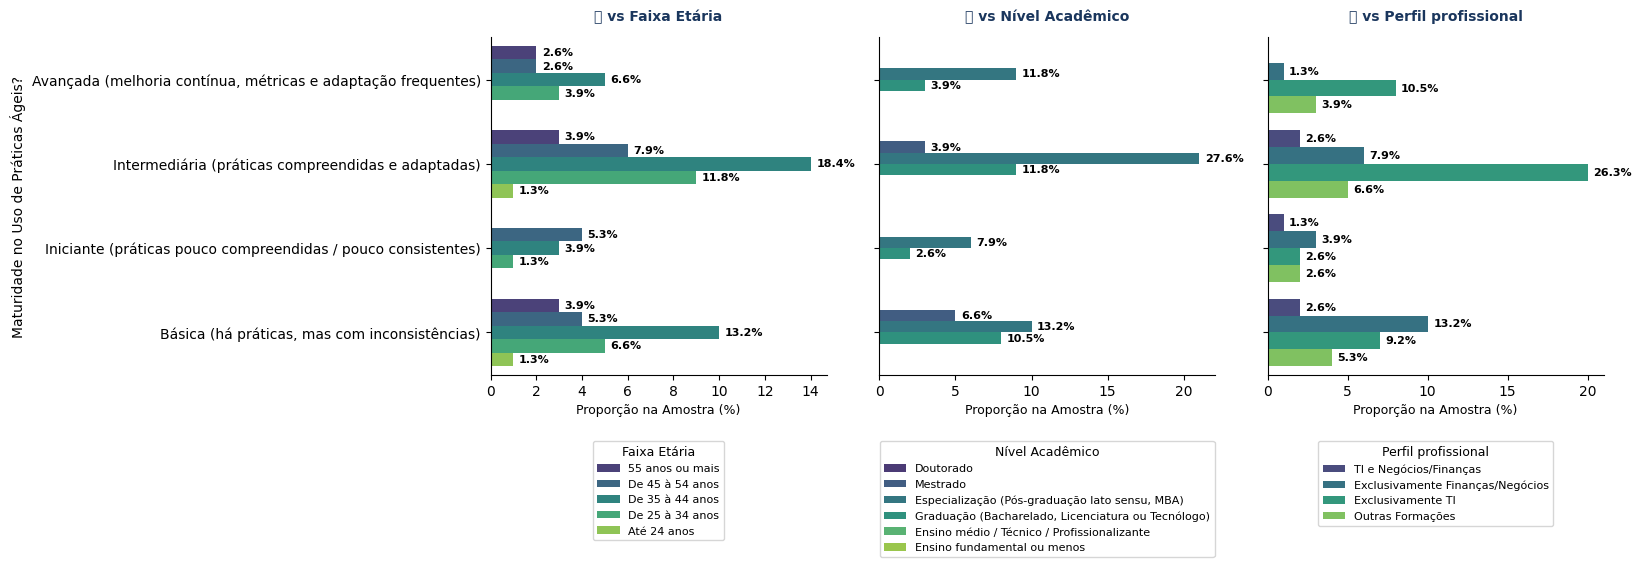

In [57]:
# Seu dicionário com as perguntas ou rótulos ideais para o documento
meu_dicionario_labels = {
    "MATURIDADE_USO_PRATICAS_AGEIS": "Maturidade no Uso de Práticas Ágeis?",
    "FAIXA_ETARIA": "Faixa Etária",
    "NIVEL_ACADEMICO": "Nível Acadêmico",
    "PERFIL_FORMACAO": "Perfil profissional"
}

# Suas listas de ordens salvas na memória
dicionario_de_ordens = {
    "FAIXA_ETARIA": ordem_idade,
    "NIVEL_ACADEMICO": ordem_nvl_academico,
    "TEMPO_ATUACAO": ordem_tempo_atuacao,
    "NIVEL_HIERARQUICO": ordem_nvl_hierarquico,
    "MATURIDADE_USO_PRATICAS_AGEIS": ordem_maturidade  # Injeção da ordem da maturidade
}

# Suas variáveis de comparação
variaveis_perfil = ["FAIXA_ETARIA", "NIVEL_ACADEMICO", "PERFIL_FORMACAO"]

# Executa o painel unificado original com as labels configuradas
gerar_painel_comparativo_labels(
    df=df_pesquisa,
    variavel_ancora="MATURIDADE_USO_PRATICAS_AGEIS",
    lista_variaveis_comparar=variaveis_perfil,
    ordens_dicionario=dicionario_de_ordens,
    dicionario_labels=meu_dicionario_labels
)

In [58]:
# 1. Cria a base exclusiva para o Setor Financeiro/Bancário
df_pesquisa_setor_fin = df_pesquisa[
    df_pesquisa['SETOR_ATUACAO'].str.contains('Financeiro/Bancário', na=False)
].copy()

# 2. Cria a base para todos os Outros Setores (tudo o que NÃO for Financeiro/Bancário)
df_pesquisa_setor_out = df_pesquisa[
    ~df_pesquisa['SETOR_ATUACAO'].str.contains('Financeiro/Bancário', na=False)
].copy()

# 3. Exibe o balanço da nova divisão amostral
print("✂️ --- SEGMENTAÇÃO POR SETOR DE ATUAÇÃO CONCLUÍDA --- 📊\n")
print(f"• Amostra Total Válida: {len(df_pesquisa)} respondentes.")
print(f"• 🏦 df_pesquisa_setor_fin: {len(df_pesquisa_setor_fin)} profissionais do Setor Financeiro.")
print(f"• 🚀 df_pesquisa_setor_out: {len(df_pesquisa_setor_out)} profissionais de Outros Setores.")

✂️ --- SEGMENTAÇÃO POR SETOR DE ATUAÇÃO CONCLUÍDA --- 📊

• Amostra Total Válida: 101 respondentes.
• 🏦 df_pesquisa_setor_fin: 64 profissionais do Setor Financeiro.
• 🚀 df_pesquisa_setor_out: 37 profissionais de Outros Setores.


### Setor financeiro/Bancario

In [59]:
df_pesquisa_setor_fin.describe()

,ID,DT_INICIO,DT_FIM,FREQ_CONTATO_SI_1A10,DOMINIO_METODOLOGIAS_AGEIS_1A10
count,64.000000,64,64,64.000000,64.000000
mean,47.921875,2026-04-12 02:56:37.781250048,2026-04-12 03:04:37.906249728,8.265625,5.671875
min,1.000000,2026-04-10 23:50:42,2026-04-10 23:56:03,0.000000,0.000000
25%,26.750000,2026-04-11 08:01:53.249999872,2026-04-11 08:05:37.750000128,8.000000,4.750000
50%,47.500000,2026-04-11 10:02:15.500000,2026-04-11 10:12:18,10.000000,7.000000
75%,70.000000,2026-04-11 15:41:38.500000,2026-04-11 15:44:18.500000,10.000000,8.000000
max,110.000000,2026-05-04 20:17:06,2026-05-04 20:26:00,10.000000,10.000000
std,28.031334,NaN,NaN,2.662152,2.856653


📊 --- PAINEL COMPARATIVO 2x2: ÂNCORA [Área de atuação: “Rigidez vs. flexibilidade”] --- 



/tmp/ipykernel_24379/1275288571.py:72: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(h_pad=4.5, w_pad=2.0)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


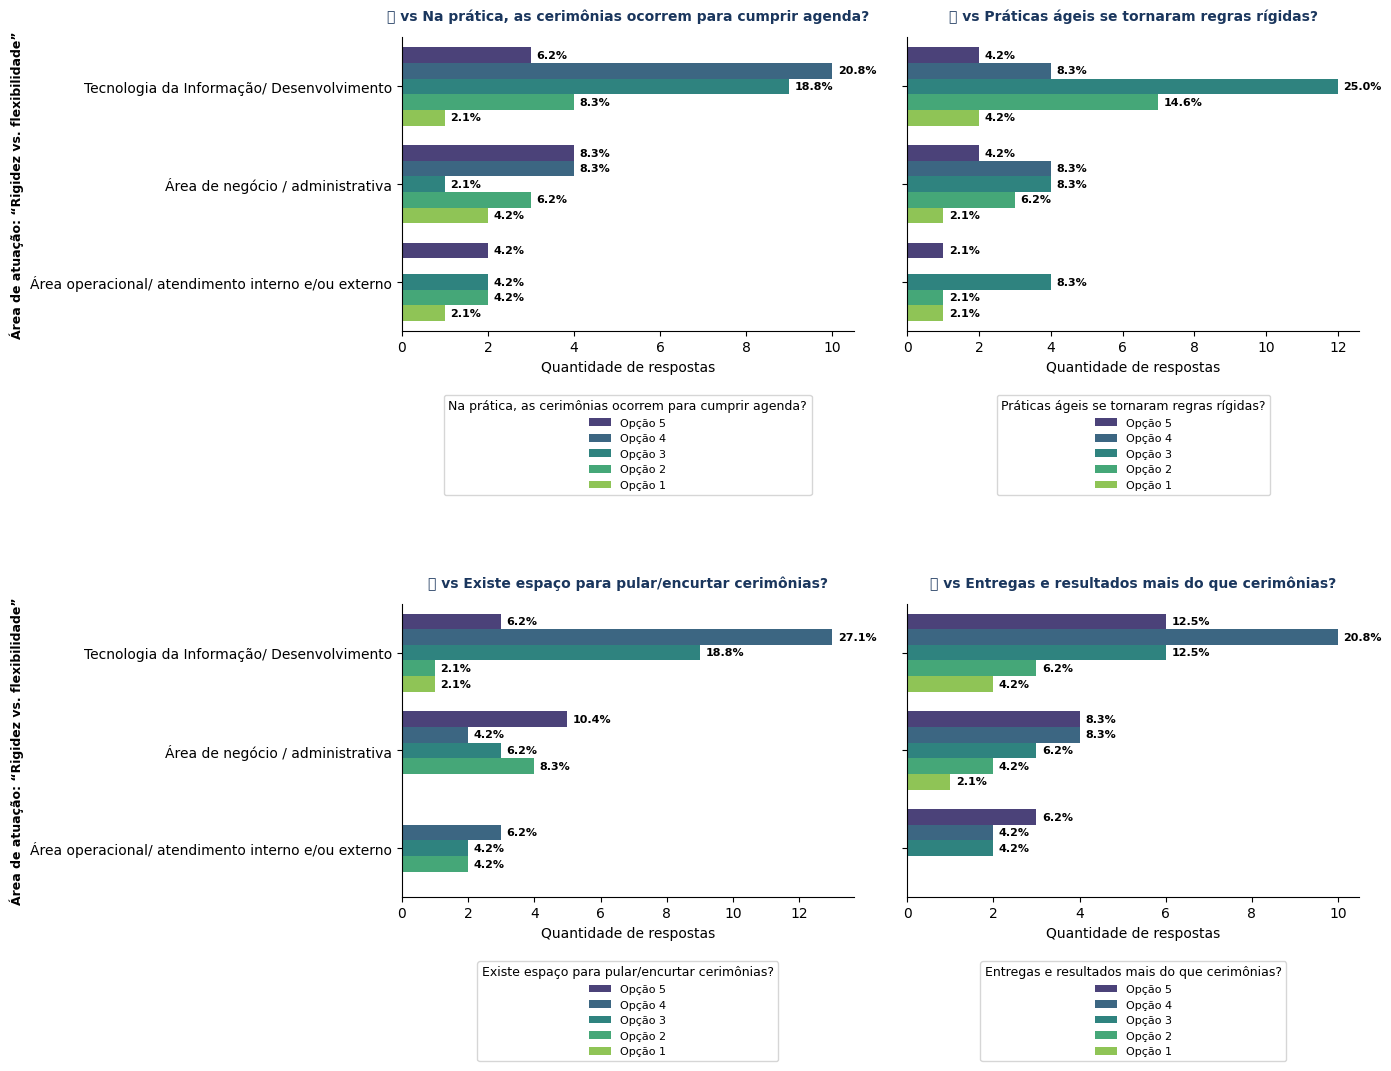

In [60]:
# Seu dicionário com as perguntas ou rótulos ideais para o documento
meu_dicionario_labels = {
    "AREA_ATUACAO_ORG" : 'Área de atuação: “Rigidez vs. flexibilidade”',
    "CERIMONIAS_CUMPRIR_AGENDA_SEM_NECESSIDADE": "Na prática, as cerimônias ocorrem para cumprir agenda?",
    "PRATICAS_REGRAS_RIGIDAS_POUCO_AJUSTAVEIS": "Práticas ágeis se tornaram regras rígidas?",
    "ESPACO_PULAR_ENCURTAR_CERIMONIAS": "Existe espaço para pular/encurtar cerimônias?",
    "PRIORIZA_ENTREGAS_VS_CUMPRIR_FRAMEWORK": "Entregas e resultados mais do que cerimônias?"
}

ordem_likert = [
    "Opção 5",
    "Opção 4",
    "Opção 3",
    "Opção 2",
    "Opção 1",
]

# Suas listas de ordens salvas na memória
dicionario_de_ordens = {
    "CERIMONIAS_CUMPRIR_AGENDA_SEM_NECESSIDADE": ordem_likert,
    "PRATICAS_REGRAS_RIGIDAS_POUCO_AJUSTAVEIS": ordem_likert,
    "ESPACO_PULAR_ENCURTAR_CERIMONIAS": ordem_likert,
    "PRIORIZA_ENTREGAS_VS_CUMPRIR_FRAMEWORK": ordem_likert,


}



# Suas variáveis de comparação
variaveis_perfil = ["CERIMONIAS_CUMPRIR_AGENDA_SEM_NECESSIDADE",
                    "PRATICAS_REGRAS_RIGIDAS_POUCO_AJUSTAVEIS",
                    "ESPACO_PULAR_ENCURTAR_CERIMONIAS",
                    "PRIORIZA_ENTREGAS_VS_CUMPRIR_FRAMEWORK"]

# Executa o painel unificado original com as labels configuradas
gerar_painel_comparativo_labels_2x2(
    df=df_pesquisa_setor_fin,
    variavel_ancora="AREA_ATUACAO_ORG",
    lista_variaveis_comparar=variaveis_perfil,
    ordens_dicionario=dicionario_de_ordens,
    dicionario_labels=meu_dicionario_labels
)



📊 --- PAINEL COMPARATIVO 2x2: ÂNCORA [Área de atuação: “Comparando squads e equipes tradicionais”] --- 



/tmp/ipykernel_24379/1275288571.py:72: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(h_pad=4.5, w_pad=2.0)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


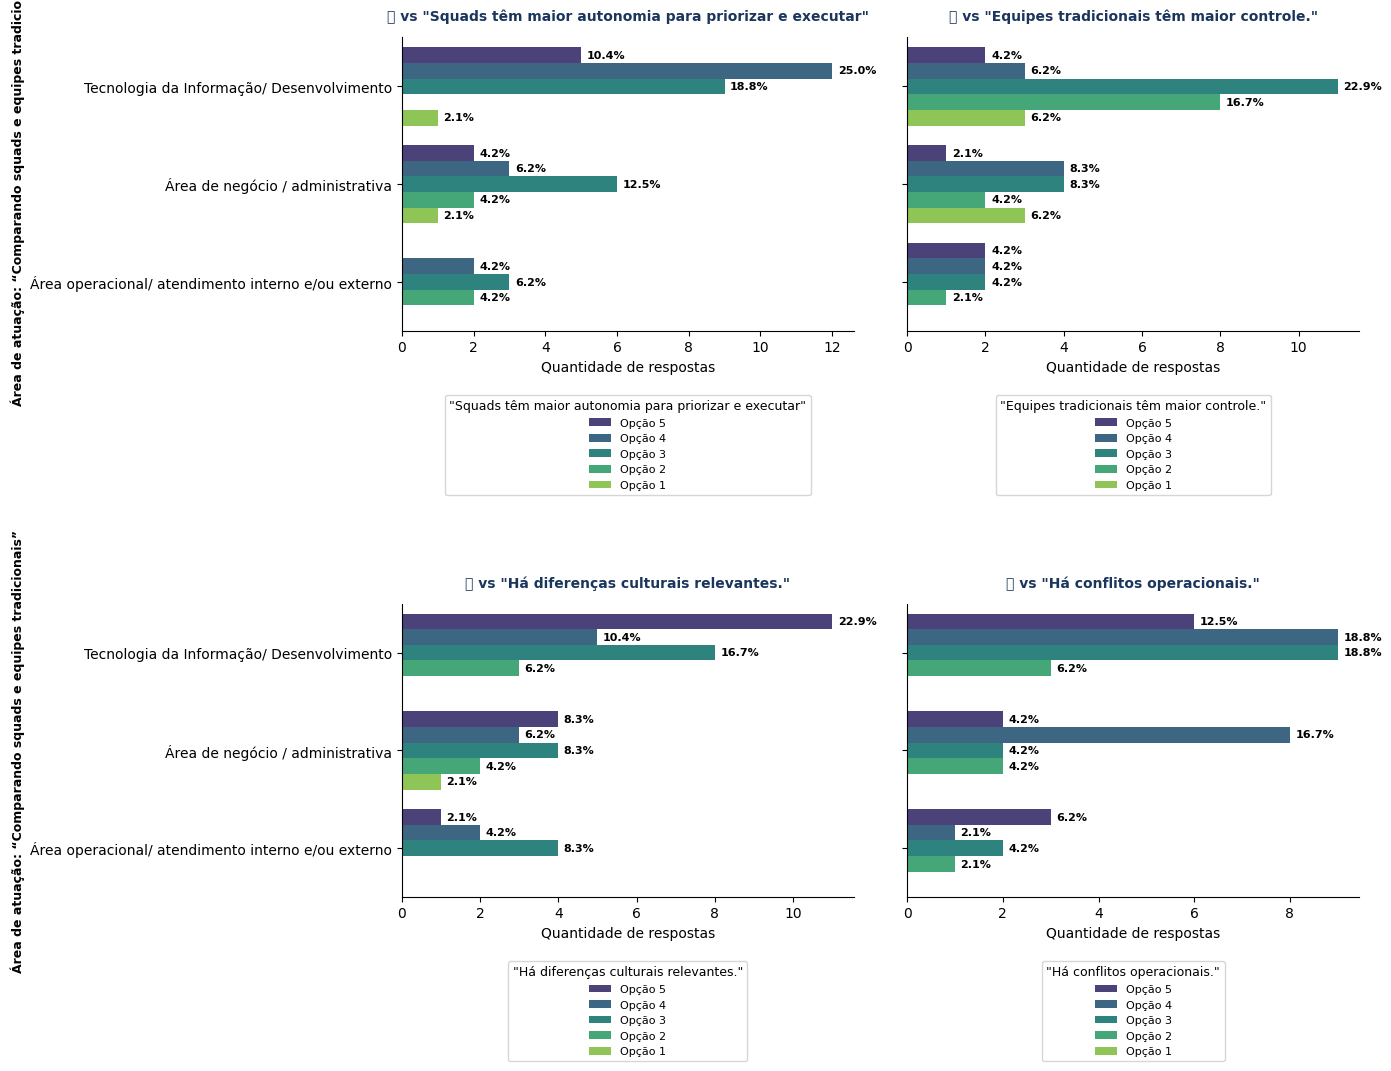

In [61]:
# Seu dicionário com as perguntas ou rótulos ideais para o documento
meu_dicionario_labels = {
    "AREA_ATUACAO_ORG" : 'Área de atuação: “Comparando squads e equipes tradicionais”',
    "SQUADS_AUTONOMIA_PRIORIZAR_EXECUTAR": '"Squads têm maior autonomia para priorizar e executar"',
    "TRADICIONAIS_GOVERNANCA_CONTROLE": '"Equipes tradicionais têm maior controle."',
    "DIFERENCAS_CULTURAIS_COLAB_TRANSP_ACCOUNT": '"Há diferenças culturais relevantes."',
    "CONFLITOS_OPERACIONAIS_RITMOS_PRAZOS_ARTEFATOS_DOC": '"Há conflitos operacionais."'
}

ordem_likert = [
    "Opção 5",
    "Opção 4",
    "Opção 3",
    "Opção 2",
    "Opção 1",
]

# Suas listas de ordens salvas na memória
dicionario_de_ordens = {
    "SQUADS_AUTONOMIA_PRIORIZAR_EXECUTAR": ordem_likert,
    "TRADICIONAIS_GOVERNANCA_CONTROLE": ordem_likert,
    "DIFERENCAS_CULTURAIS_COLAB_TRANSP_ACCOUNT": ordem_likert,
    "CONFLITOS_OPERACIONAIS_RITMOS_PRAZOS_ARTEFATOS_DOC": ordem_likert,


}



# Suas variáveis de comparação
variaveis_perfil = ["SQUADS_AUTONOMIA_PRIORIZAR_EXECUTAR",
                    "TRADICIONAIS_GOVERNANCA_CONTROLE",
                    "DIFERENCAS_CULTURAIS_COLAB_TRANSP_ACCOUNT",
                    "CONFLITOS_OPERACIONAIS_RITMOS_PRAZOS_ARTEFATOS_DOC"]

# Executa o painel unificado original com as labels configuradas
gerar_painel_comparativo_labels_2x2(
    df=df_pesquisa_setor_fin,
    variavel_ancora="AREA_ATUACAO_ORG",
    lista_variaveis_comparar=variaveis_perfil,
    ordens_dicionario=dicionario_de_ordens,
    dicionario_labels=meu_dicionario_labels
)


📊 --- PAINEL COMPARATIVO 2x2: ÂNCORA [Área de atuação: “Rituais percebidos como burocracia improdutiva”] --- 



/tmp/ipykernel_24379/1275288571.py:72: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout(h_pad=4.5, w_pad=2.0)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


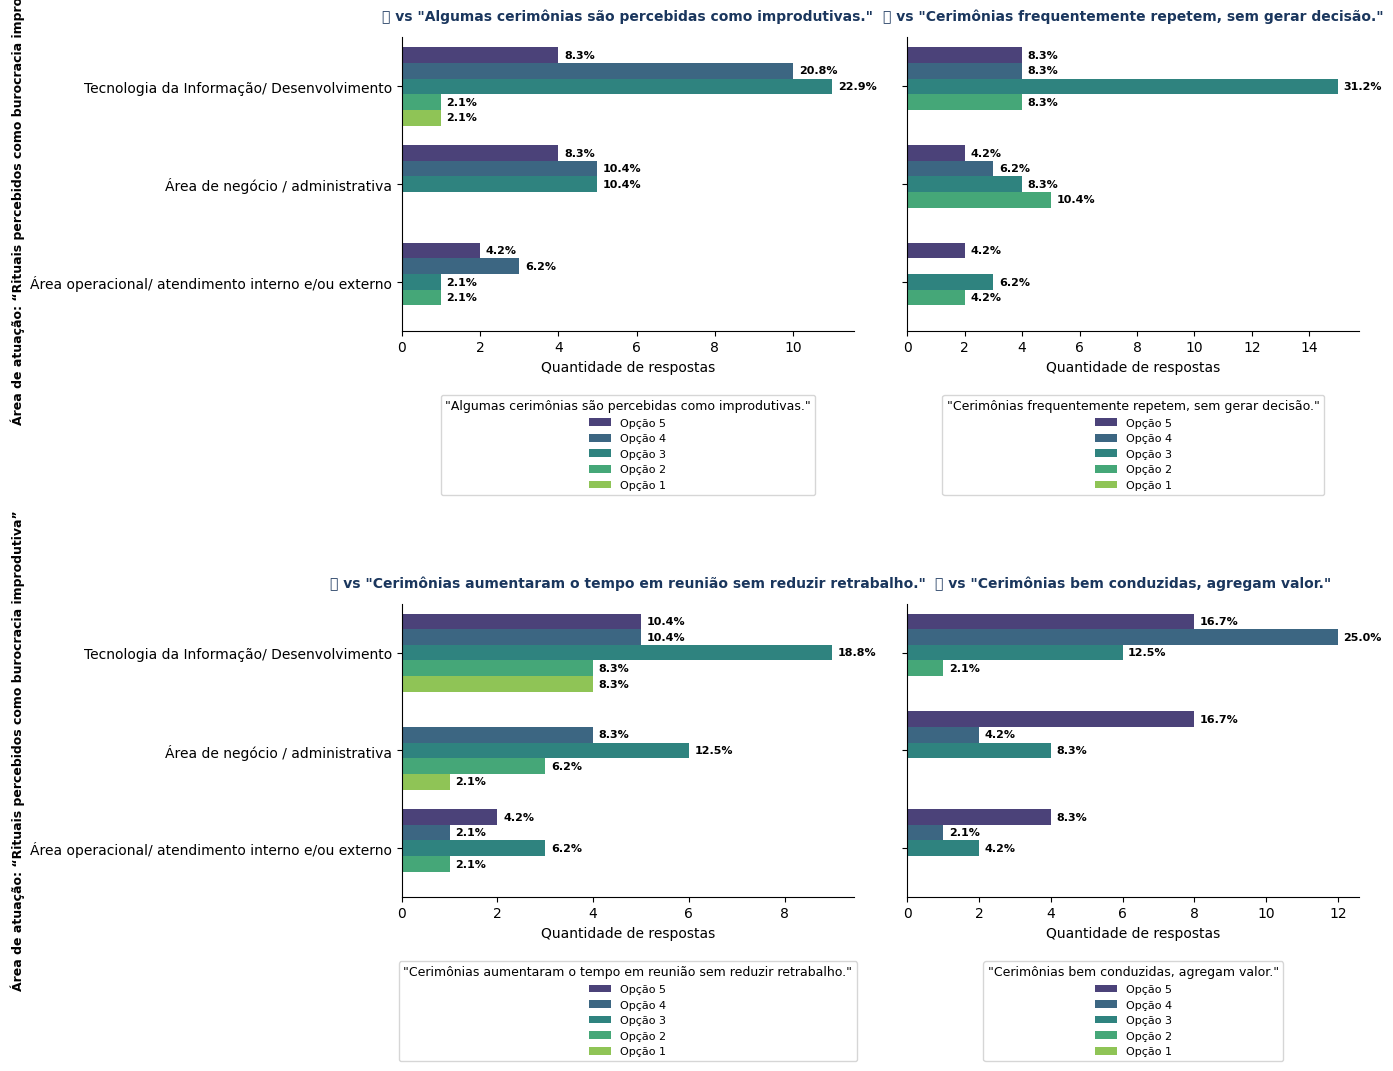

In [62]:
# Seu dicionário com as perguntas ou rótulos ideais para o documento
meu_dicionario_labels = {
    "AREA_ATUACAO_ORG" : 'Área de atuação: “Rituais percebidos como burocracia improdutiva”',
    "CERIMONIAS_IMPRODUTIVAS": '"Algumas cerimônias são percebidas como improdutivas."',
    "CERIMONIAS_REPETEM_SEM_DECISAO": '"Cerimônias frequentemente repetem, sem gerar decisão."',
    "MAIS_REUNIAO_SEM_REDUZIR_RETRABALHO": '"Cerimônias aumentaram o tempo em reunião sem reduzir retrabalho."',
    "CERIMONIAS_AGREGAM_VALOR_REV": '"Cerimônias bem conduzidas, agregam valor."'
}

ordem_likert = [
    "Opção 5",
    "Opção 4",
    "Opção 3",
    "Opção 2",
    "Opção 1",
]

# Suas listas de ordens salvas na memória
dicionario_de_ordens = {
    "CERIMONIAS_IMPRODUTIVAS": ordem_likert,
    "CERIMONIAS_REPETEM_SEM_DECISAO": ordem_likert,
    "MAIS_REUNIAO_SEM_REDUZIR_RETRABALHO": ordem_likert,
    "CERIMONIAS_AGREGAM_VALOR_REV": ordem_likert,


}



# Suas variáveis de comparação
variaveis_perfil = ["CERIMONIAS_IMPRODUTIVAS",
                    "CERIMONIAS_REPETEM_SEM_DECISAO",
                    "MAIS_REUNIAO_SEM_REDUZIR_RETRABALHO",
                    "CERIMONIAS_AGREGAM_VALOR_REV"]

# Executa o painel unificado original com as labels configuradas
gerar_painel_comparativo_labels_2x2(
    df=df_pesquisa_setor_fin,
    variavel_ancora="AREA_ATUACAO_ORG",
    lista_variaveis_comparar=variaveis_perfil,
    ordens_dicionario=dicionario_de_ordens,
    dicionario_labels=meu_dicionario_labels
)


🔄 --- ANÁLISE EM QUADROS (PERCENTUAL % COM RÓTULOS): BUROCRACIA_IMPRODUTIVA_QUAIS_CERIMONIAS_ATE2 por AREA_ATUACAO_ORG --- 📊

📋 Tabela de Frequência Absoluta (Contagem):


AREA_ATUACAO_ORG,Tecnologia da Informação/ Desenvolvimento,Área de negócio / administrativa,Área operacional/ atendimento interno e/ou externo
BUROCRACIA_IMPRODUTIVA_QUAIS_CERIMONIAS_ATE2,,,
Acompanhamentos;,1,1,0
Acompanhamentos;Daily;,0,2,0
Acompanhamentos;Retrospectivas;,1,2,0
Acompanhamentos;Revisões;,1,0,0
Daily;,5,2,2
Daily;Acompanhamentos;,2,0,0
Daily;Planejamento;,0,0,1
Daily;Retrospectivas;,2,0,1
Daily;Revisões,1,0,0



📈 Tabela Percentual Relativa (Distribuição % por coluna/quadro):


AREA_ATUACAO_ORG,Tecnologia da Informação/ Desenvolvimento,Área de negócio / administrativa,Área operacional/ atendimento interno e/ou externo
BUROCRACIA_IMPRODUTIVA_QUAIS_CERIMONIAS_ATE2,,,
Acompanhamentos;,3.7,7.1,0.0
Acompanhamentos;Daily;,0.0,14.3,0.0
Acompanhamentos;Retrospectivas;,3.7,14.3,0.0
Acompanhamentos;Revisões;,3.7,0.0,0.0
Daily;,18.5,14.3,28.6
Daily;Acompanhamentos;,7.4,0.0,0.0
Daily;Planejamento;,0.0,0.0,14.3
Daily;Retrospectivas;,7.4,0.0,14.3
Daily;Revisões,3.7,0.0,0.0



--------------------------------------------------------------------------------



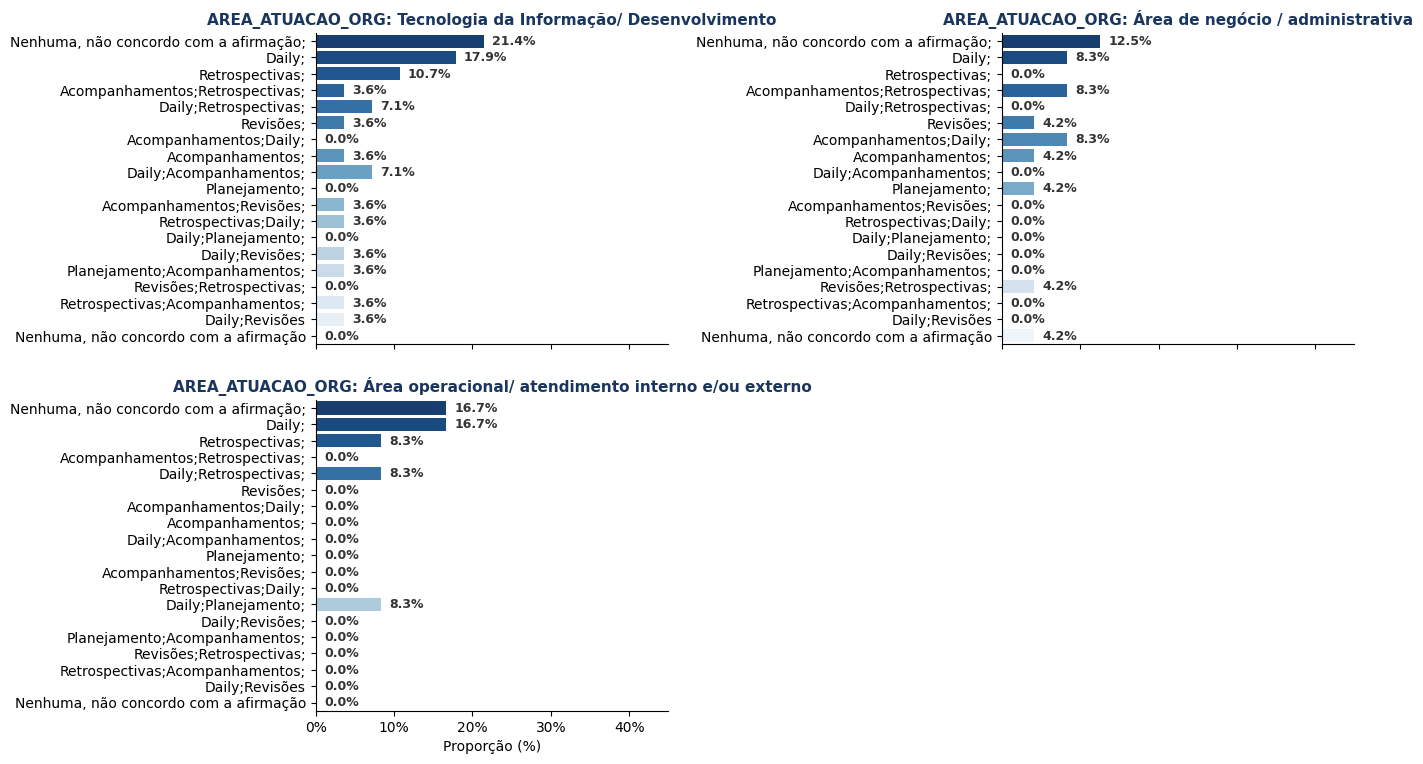

In [63]:
analisar_cruzamento_separado_pct(df_pesquisa_setor_fin,
                                 'BUROCRACIA_IMPRODUTIVA_QUAIS_CERIMONIAS_ATE2',
                                 'AREA_ATUACAO_ORG',)

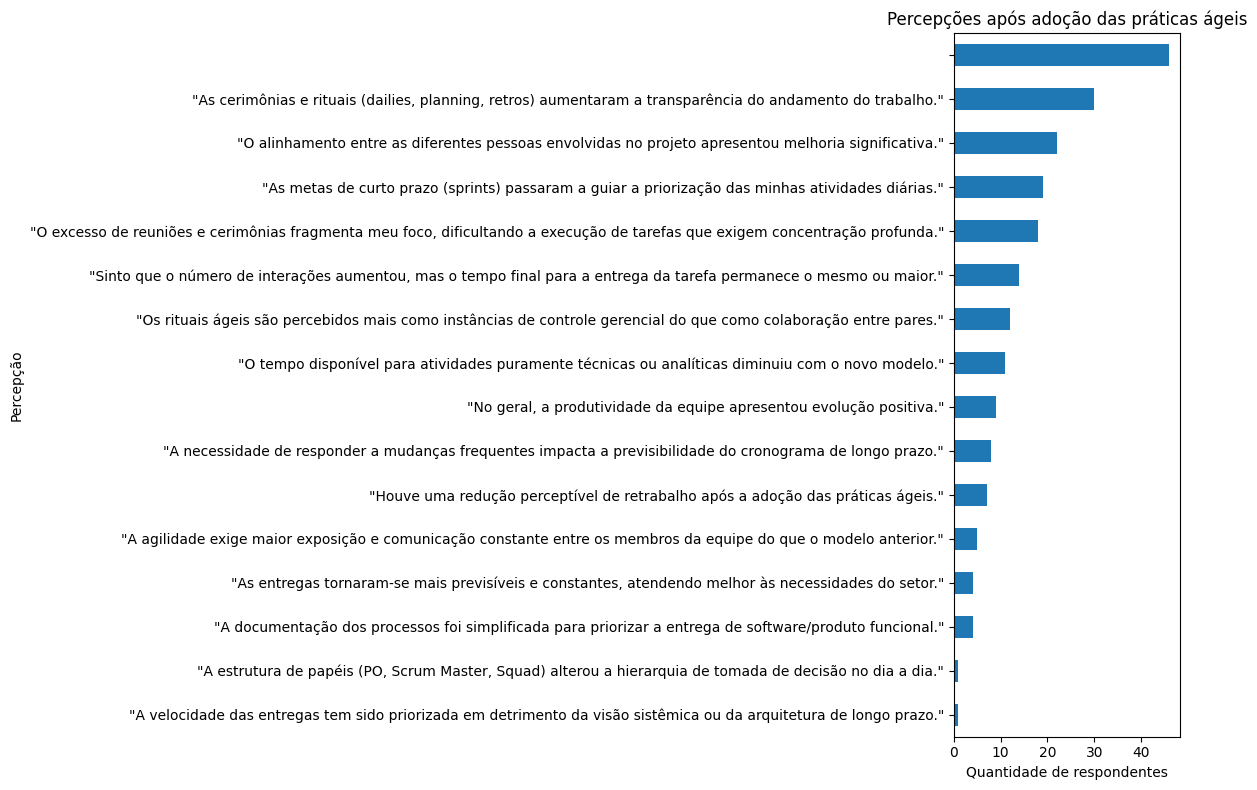

In [64]:
# Separar respostas múltiplas
df_blocos = (
    df_pesquisa_setor_fin['POS_ADOCAO_PERCEBO_QUE']
    .dropna()
    .str.split(';')
    .explode()
    .str.strip()
)

# Contagem das frequências
freq = df_blocos.value_counts()

# Gráfico
plt.figure(figsize=(12, 8))

freq.sort_values().plot(
    kind='barh'
)

plt.title('Percepções após adoção das práticas ágeis')
plt.xlabel('Quantidade de respondentes')
plt.ylabel('Percepção')

plt.tight_layout()
plt.show()

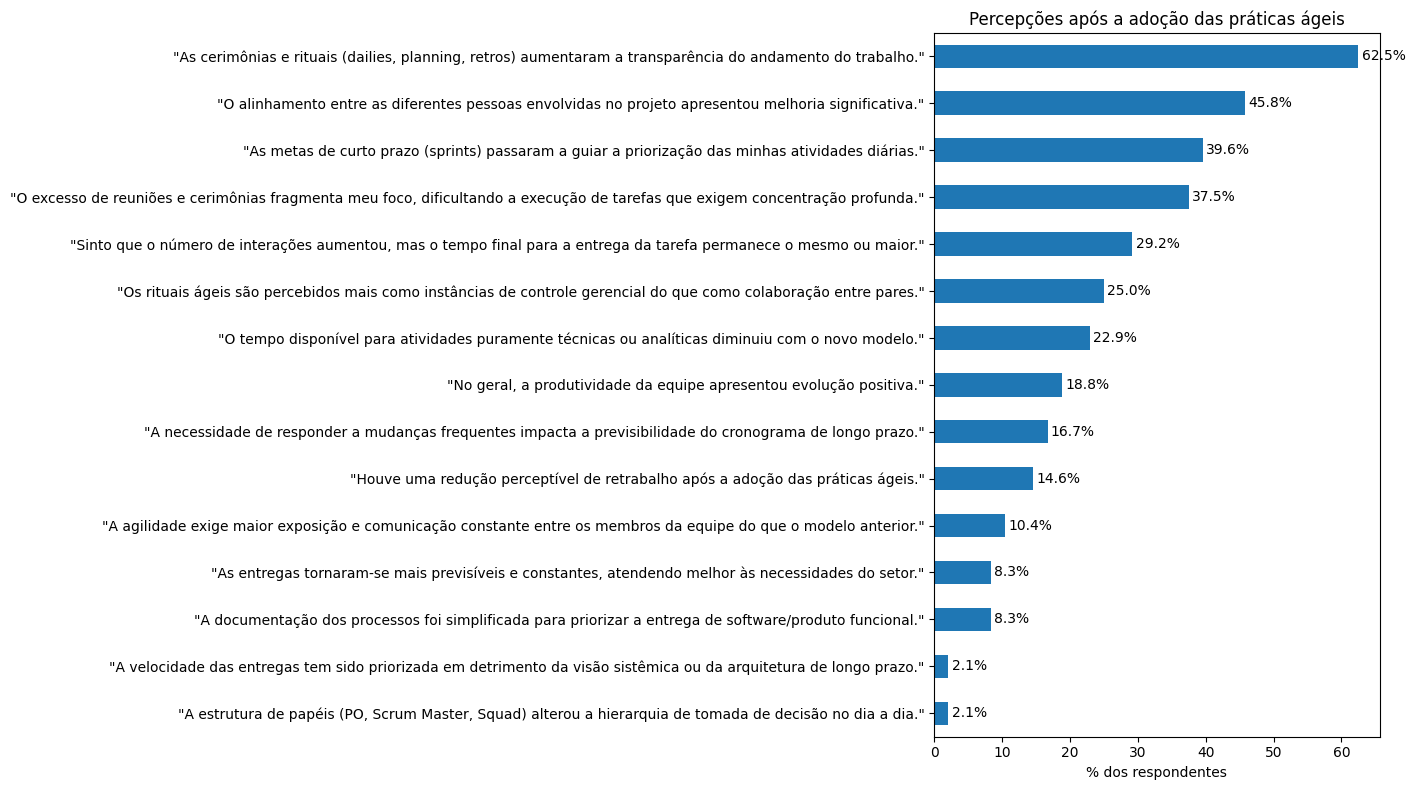

In [65]:
# Total de respondentes válidos
total_resp = df_pesquisa_setor_fin['POS_ADOCAO_PERCEBO_QUE'].notna().sum()

# Explode
df_blocos = (
    df_pesquisa_setor_fin['POS_ADOCAO_PERCEBO_QUE']
    .dropna()
    .str.rstrip(';')      # remove ; do final
    .str.split(';')
    .explode()
    .str.strip()
)


# Frequência e percentual
freq = df_blocos.value_counts()

perc = (freq / total_resp * 100).round(1)

# Gráfico
fig, ax = plt.subplots(figsize=(14, 8))

perc.sort_values().plot(
    kind='barh',
    ax=ax
)

# Rótulos
for i, v in enumerate(perc.sort_values()):
    ax.text(v + 0.5, i, f'{v:.1f}%', va='center')

ax.set_title('Percepções após a adoção das práticas ágeis')
ax.set_xlabel('% dos respondentes')
ax.set_ylabel('')

plt.tight_layout()
plt.show()

🔄 --- ANÁLISE EM QUADROS (PERCENTUAL % COM RÓTULOS): SETOR_REGULADO_ABORDAGEM_MELHOR por AREA_ATUACAO_ORG --- 📊

📋 Tabela de Frequência Absoluta (Contagem):


AREA_ATUACAO_ORG,Tecnologia da Informação/ Desenvolvimento,Área de negócio / administrativa,Área operacional/ atendimento interno e/ou externo
SETOR_REGULADO_ABORDAGEM_MELHOR,,,
Depende do tipo de atividade/demanda,1,2,2
Framework ágil “puro” (Scrum/Kanban aplicado como padrão),6,0,1
Modelo híbrido (combina práticas tradicionais e ágeis conforme a demanda),16,11,4
Modelo tradicional (maior previsibilidade e controle formal),1,1,0
Não sei informar,3,0,0



📈 Tabela Percentual Relativa (Distribuição % por coluna/quadro):


AREA_ATUACAO_ORG,Tecnologia da Informação/ Desenvolvimento,Área de negócio / administrativa,Área operacional/ atendimento interno e/ou externo
SETOR_REGULADO_ABORDAGEM_MELHOR,,,
Depende do tipo de atividade/demanda,3.7,14.3,28.6
Framework ágil “puro” (Scrum/Kanban aplicado como padrão),22.2,0.0,14.3
Modelo híbrido (combina práticas tradicionais e ágeis conforme a demanda),59.3,78.6,57.1
Modelo tradicional (maior previsibilidade e controle formal),3.7,7.1,0.0
Não sei informar,11.1,0.0,0.0



--------------------------------------------------------------------------------



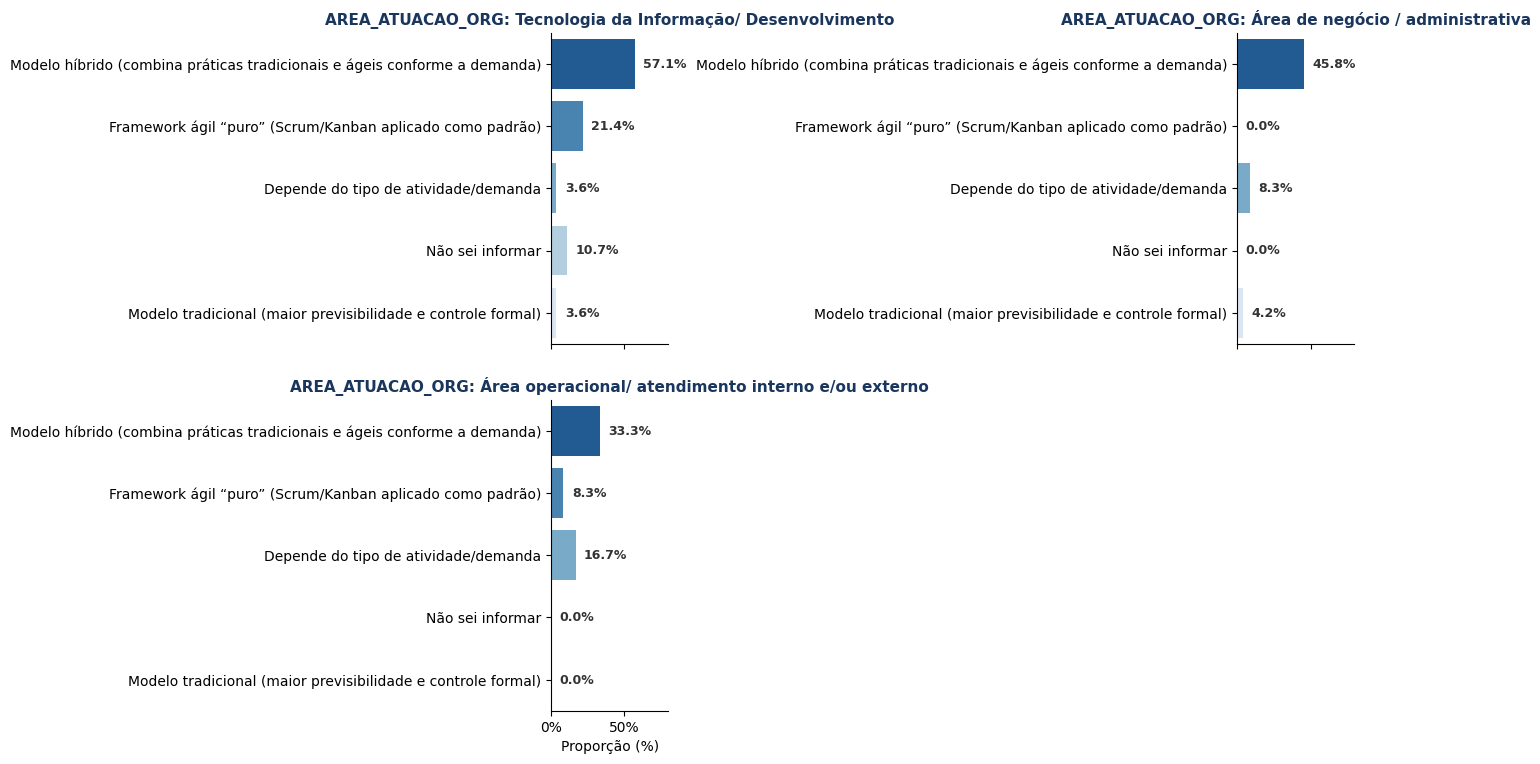

In [66]:
analisar_cruzamento_separado_pct(df_pesquisa_setor_fin,
                                 'SETOR_REGULADO_ABORDAGEM_MELHOR',
                                 'AREA_ATUACAO_ORG',)

📊 --- ANÁLISE COMPLETA: SETOR_REGULADO_ABORDAGEM_MELHOR --- 📊

                                                    Frequência Absoluta  \
SETOR_REGULADO_ABORDAGEM_MELHOR                                           
Modelo híbrido (combina práticas tradicionais e...                   41   
Depende do tipo de atividade/demanda                                 12   
Framework ágil “puro” (Scrum/Kanban aplicado co...                   11   
Não sei informar                                                      9   
Modelo tradicional (maior previsibilidade e con...                    3   

                                                    Proporção (%)  
SETOR_REGULADO_ABORDAGEM_MELHOR                                    
Modelo híbrido (combina práticas tradicionais e...          53.95  
Depende do tipo de atividade/demanda                        15.79  
Framework ágil “puro” (Scrum/Kanban aplicado co...          14.47  
Não sei informar                                            11.84  
Mod

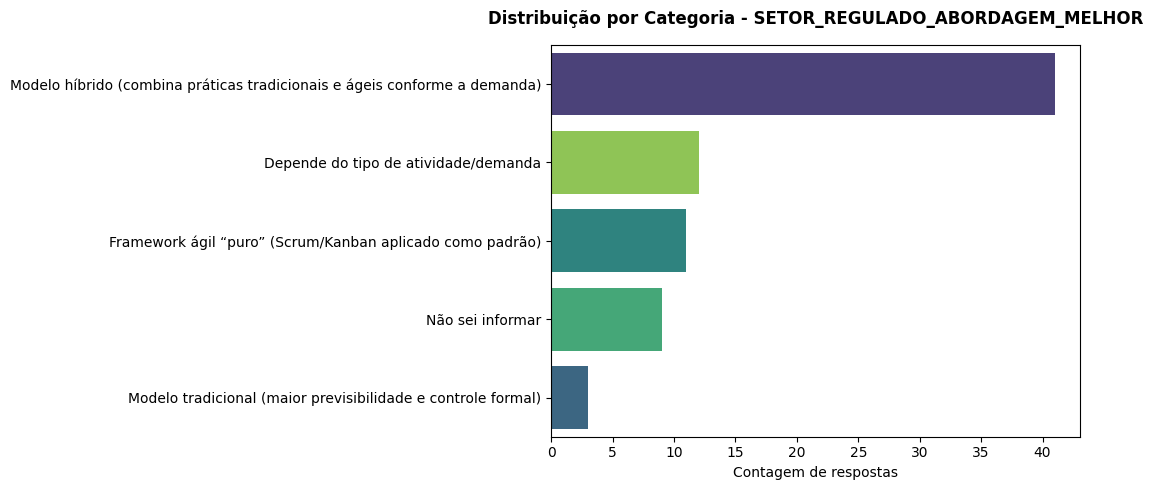

In [67]:
analisar_coluna(df_pesquisa,'SETOR_REGULADO_ABORDAGEM_MELHOR')

🔄 --- ANÁLISE EM QUADROS (PERCENTUAL % COM RÓTULOS): LIMITADORES_ADOCAO_FATOR_DETERMINANTE_1OP por SETOR_ATUACAO --- 📊

📋 Tabela de Frequência Absoluta (Contagem):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
LIMITADORES_ADOCAO_FATOR_DETERMINANTE_1OP,,
Cultura de comando-controle / hierarquia,2,4
Falta de capacitação em agilidade,2,4
"Dependências de múltiplas áreas (jurídico, risco, TI, etc.)",5,16
Exigências de auditoria/compliance,3,3
Falta de autonomia para priorizar,1,2
Ferramentas inadequadas,2,1
Necessidade de documentação formal,0,6
Não identifiquei fatores que limitam a adoção em minha área,1,8
Não sei informar,3,0



📈 Tabela Percentual Relativa (Distribuição % por coluna/quadro):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
LIMITADORES_ADOCAO_FATOR_DETERMINANTE_1OP,,
Cultura de comando-controle / hierarquia,7.1,8.3
Falta de capacitação em agilidade,7.1,8.3
"Dependências de múltiplas áreas (jurídico, risco, TI, etc.)",17.9,33.3
Exigências de auditoria/compliance,10.7,6.2
Falta de autonomia para priorizar,3.6,4.2
Ferramentas inadequadas,7.1,2.1
Necessidade de documentação formal,0.0,12.5
Não identifiquei fatores que limitam a adoção em minha área,3.6,16.7
Não sei informar,10.7,0.0



--------------------------------------------------------------------------------



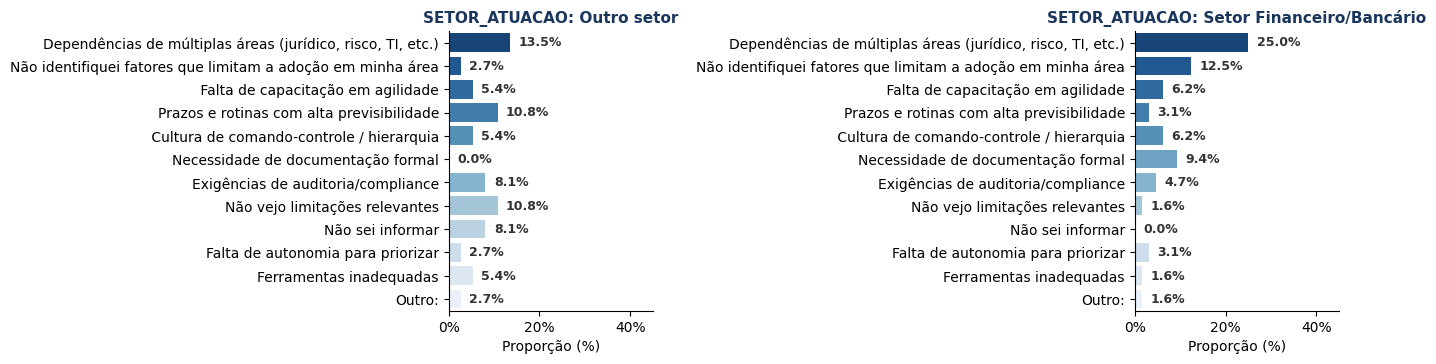

In [69]:
analisar_cruzamento_separado_pct(df_pesquisa,'LIMITADORES_ADOCAO_FATOR_DETERMINANTE_1OP','SETOR_ATUACAO')

In [70]:
df_pesquisa['LIMITADORES_ADOCAO_FATOR_DETERMINANTE_1OP'].unique()

array(['Dependências de múltiplas áreas (jurídico, risco, TI, etc.)',
       ' Falta de capacitação em agilidade', nan,
       'Não identifiquei fatores que limitam a adoção em minha área',
       'Prazos e rotinas com alta previsibilidade', 'Não sei informar',
       'Não vejo limitações relevantes',
       'Necessidade de documentação formal',
       ' Cultura de comando-controle / hierarquia',
       'Exigências de auditoria/compliance', 'Outro:',
       'Falta de autonomia para priorizar', 'Ferramentas inadequadas'],
      dtype=object)

In [71]:
df_pesquisa['LIMITADORES_ADOCAO_FATOR_DETERMINANTE_1OP'] = (
    df_pesquisa['LIMITADORES_ADOCAO_FATOR_DETERMINANTE_1OP']
    .replace(r'^\s*$', np.nan, regex=True)  # strings vazias ou apenas espaços
    .replace({
        'Outro:': 'Outros / Não informado',
        'Não sei informar': 'Outros / Não informado'
    })
    .fillna('Outros / Não informado')
    .str.strip()
)



In [72]:
df_pesquisa['LIMITADORES_ADOCAO_FATOR_DETERMINANTE_1OP'].value_counts(dropna=False)

,count
LIMITADORES_ADOCAO_FATOR_DETERMINANTE_1OP,
Outros / Não informado,30
"Dependências de múltiplas áreas (jurídico, risco, TI, etc.)",21
Não identifiquei fatores que limitam a adoção em minha área,9
Falta de capacitação em agilidade,6
Prazos e rotinas com alta previsibilidade,6
Necessidade de documentação formal,6
Cultura de comando-controle / hierarquia,6
Exigências de auditoria/compliance,6
Não vejo limitações relevantes,5


In [73]:
ordem_limitadores2 = [
    'Exigências de auditoria/compliance',
    'Necessidade de documentação formal',
    'Dependências de múltiplas áreas (jurídico, risco, TI, etc.)',
    'Prazos e rotinas com alta previsibilidade',
    'Cultura de comando-controle / hierarquia',
    'Falta de autonomia para priorizar',
    'Falta de capacitação em agilidade',
    'Ferramentas inadequadas',
    'Não vejo limitações relevantes',
    #'Não sei informar',
    'Não identifiquei fatores que limitam a adoção em minha área',
    #'Outro:',
    'Outros / Não informado',

]

🔄 --- ANÁLISE EM QUADROS (PERCENTUAL % COM RÓTULOS): LIMITADORES_ADOCAO_FATOR_DETERMINANTE_1OP por SETOR_ATUACAO --- 📊

📋 Tabela de Frequência Absoluta (Contagem):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
LIMITADORES_ADOCAO_FATOR_DETERMINANTE_1OP,,
Exigências de auditoria/compliance,3,3
Necessidade de documentação formal,0,6
"Dependências de múltiplas áreas (jurídico, risco, TI, etc.)",5,16
Prazos e rotinas com alta previsibilidade,4,2
Cultura de comando-controle / hierarquia,2,4
Falta de autonomia para priorizar,1,2
Falta de capacitação em agilidade,2,4
Ferramentas inadequadas,2,1
Não vejo limitações relevantes,4,1



📈 Tabela Percentual Relativa (Distribuição % por coluna/quadro):


SETOR_ATUACAO,Outro setor,Setor Financeiro/Bancário
LIMITADORES_ADOCAO_FATOR_DETERMINANTE_1OP,,
Exigências de auditoria/compliance,8.1,4.7
Necessidade de documentação formal,0.0,9.4
"Dependências de múltiplas áreas (jurídico, risco, TI, etc.)",13.5,25.0
Prazos e rotinas com alta previsibilidade,10.8,3.1
Cultura de comando-controle / hierarquia,5.4,6.2
Falta de autonomia para priorizar,2.7,3.1
Falta de capacitação em agilidade,5.4,6.2
Ferramentas inadequadas,5.4,1.6
Não vejo limitações relevantes,10.8,1.6



--------------------------------------------------------------------------------



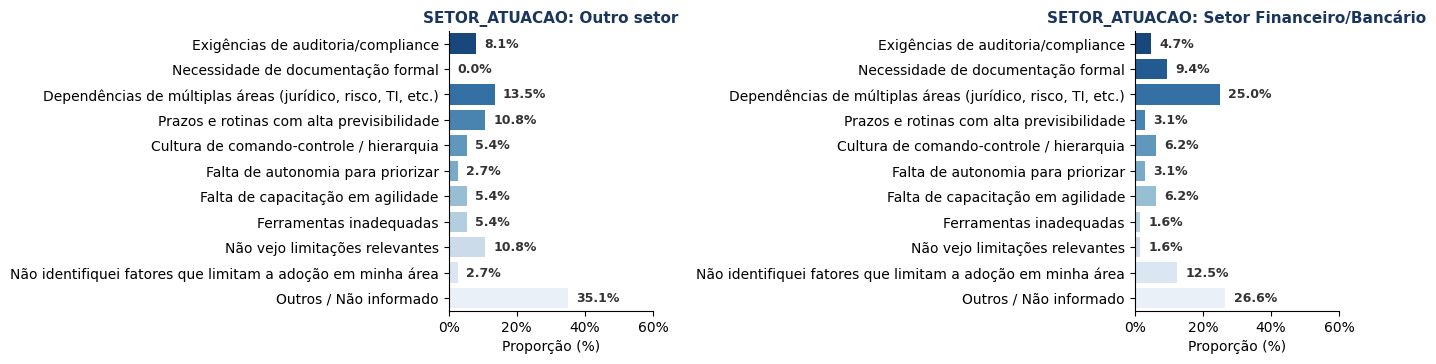

In [74]:
analisar_cruzamento_separado_pct(df_pesquisa,'LIMITADORES_ADOCAO_FATOR_DETERMINANTE_1OP','SETOR_ATUACAO',ordem_limitadores2)

📊 --- ANÁLISE COMPLETA: LIMITADORES_ADOCAO_FATOR_DETERMINANTE_1OP --- 📊

                                                    Frequência Absoluta  \
LIMITADORES_ADOCAO_FATOR_DETERMINANTE_1OP                                 
Outros / Não informado                                               30   
Dependências de múltiplas áreas (jurídico, risc...                   21   
Não identifiquei fatores que limitam a adoção e...                    9   
Falta de capacitação em agilidade                                     6   
Prazos e rotinas com alta previsibilidade                             6   
Necessidade de documentação formal                                    6   
Cultura de comando-controle / hierarquia                              6   
Exigências de auditoria/compliance                                    6   
Não vejo limitações relevantes                                        5   
Falta de autonomia para priorizar                                     3   
Ferramentas inadequadas    

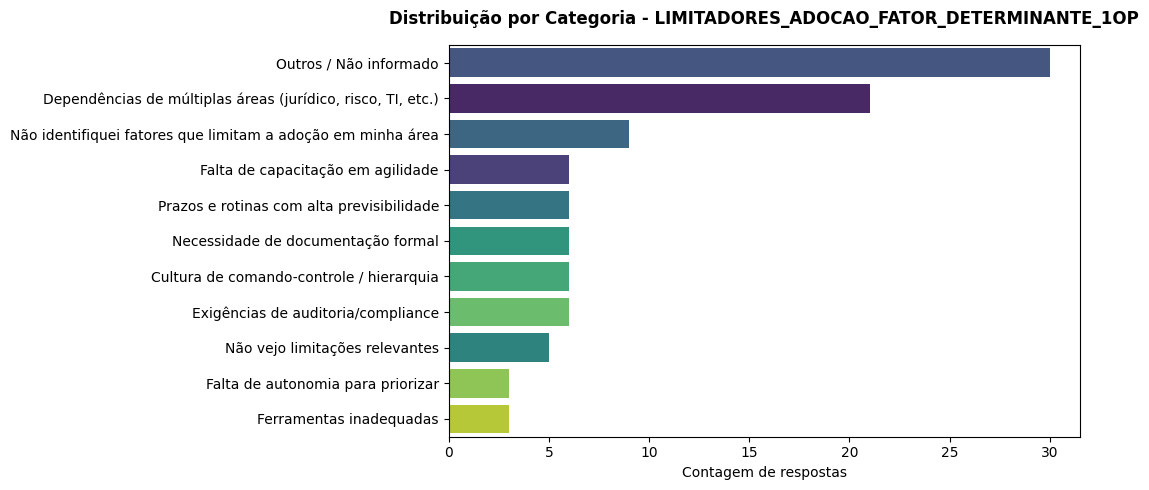

In [75]:
analisar_coluna(df_pesquisa,'LIMITADORES_ADOCAO_FATOR_DETERMINANTE_1OP')